In [1]:
import os, io, glob, platform, glob, copy, random, logging, hashlib
import requests
import numpy as np
import torch
import torch.nn as nn
import open3d as o3d
import laspy
import joblib
import mlflow
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger(__name__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info(f"Running on: {DEVICE}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-07-23 01:17:10,234 | INFO | Running on: cuda


In [2]:
import io, os, glob, socket, urllib.parse
import gdown
USE_GOOGLE_DRIVE = False
GDRIVE_FOLDER_ID = "https://drive.google.com/drive/folders/1fUCLmHNBI5gCP4w1Z-qA49Lkq4V_8xhC?usp=sharing"
LOCAL_DATA_DIR   = "data/train_v1"
RAM_STORE = {}
def _load_from_drive(folder_id):
    folder_id = urllib.parse.urlparse(folder_id).path.rstrip("/").split("/")[-1]
    _old_timeout = socket.getdefaulttimeout()
    socket.setdefaulttimeout(60)
    try:
        try:
            entries = gdown.download_folder(id=folder_id, skip_download=True, quiet=True)
        except (TimeoutError, socket.timeout) as e:
            raise RuntimeError(
                f"Timed out listing Drive folder {folder_id!r} after 60s. "
                f"Check your network connection, or that the folder is "
                f"actually shared as 'Anyone with the link'.") from e
    finally:
        socket.setdefaulttimeout(_old_timeout)
    entries = [e for e in entries
              if e.local_path.lower().endswith((".las", ".laz"))]
    if not entries:
        raise RuntimeError(
            "No .las/.laz files found in that folder. Check GDRIVE_FOLDER_ID "
            "and that the folder is shared as 'Anyone with the link'.")
    for e in entries:
        name = os.path.basename(e.local_path)
        buf = io.BytesIO()
        _old_timeout = socket.getdefaulttimeout()
        socket.setdefaulttimeout(60)
        try:
            try:
                gdown.download(id=e.id, output=buf, quiet=True)
            except (TimeoutError, socket.timeout) as ex:
                raise RuntimeError(
                    f"Timed out downloading {name!r} after 60s — Drive may be "
                    f"rate-limiting or the connection stalled. Try again, or "
                    f"download this one file manually to confirm connectivity."
                ) from ex
        finally:
            socket.setdefaulttimeout(_old_timeout)
        buf.seek(0)
        RAM_STORE[name] = buf.getvalue()
        log.info(f"  downloaded {name} "
                 f"({len(RAM_STORE[name]) / (1024**2):.1f} MB) into RAM")
def _list_local_files(folder):
    files = []
    for ext in (".las", ".laz"):
        files += glob.glob(os.path.join(folder, "*" + ext))
    files = sorted(files)
    if not files:
        raise RuntimeError(f"No .las/.laz files found in {folder!r}.")
    log.info(f"Found {len(files)} local file(s) in {folder!r} "
             f"(read directly from disk on demand — not duplicated into RAM)")
    return files
def load_dataset_source():
    if USE_GOOGLE_DRIVE:
        log.info(f"Loading dataset from Google Drive (folder {GDRIVE_FOLDER_ID!r})…")
        _load_from_drive(GDRIVE_FOLDER_ID)
        files = sorted(RAM_STORE.keys())
        total_mb = sum(len(b) for b in RAM_STORE.values()) / (1024**2)
        log.info(f"Loaded {len(files)} files into RAM_STORE ({total_mb:.1f} MB total)")
    else:
        files = _list_local_files(LOCAL_DATA_DIR)
    return files
ALL_FILES = load_dataset_source()

2026-07-23 01:17:10,277 | INFO | Found 45 local file(s) in 'data/train_v1' (read directly from disk on demand — not duplicated into RAM)


In [3]:
CONFIG = {
    "checkpoint_dir" : "checkpoints/PT_v2_17_channel_v57_6_layer",
    "num_classes"    : 2,
    "target_class"   : 1,
    "val_ratio"      : 0.15,
    "test_ratio"     : 0.15,
    "cv_folds"       : 5,
    "seed"           : 42,
    "epochs"         : 50,
    "patience"       : 10,
    "batch_size"     : 4,
    "grad_accum"     : 1,
    "num_points"     : 8192,
    "chunks_per_cloud": 120,
    "lr"             : 2e-4,
    "sched_factor"   : 0.5,
    "sched_patience" : 10,
    "min_lr"         : 1e-6,
    "voxel_size"     : 0.01,
    "normal_radius"  : 0.05,
    "normal_max_nn"  : 30,
    "sor_enabled"    : True,
    "sor_k"          : 16,
    "sor_std"        : 2.0,
    "cluster_filter_enabled": True,
    "cluster_eps"    : 0.03,
    "cluster_min_size": 100,
    "aug_jitter"     : 0.01,
    "aug_scale"      : 0.1,
    "aug_dropout"    : 0.10,
    "debug_anomaly_detection": True,
    "model_dims"     : (48, 96, 192, 384, 768, 1536),
    "model_k"        : 16,
    "model_groups"   : 6,
    "use_linearity"    : True,
    "use_planarity"    : True,
    "use_sphericity"   : True,
    "use_verticality"  : True,
    "use_eigenentropy" : True,
    "use_height_std"   : True,
    "use_height_range" : True,
    "use_curvature"    : True,
    "use_roughness"    : True,
    "use_density"      : False,
    "use_mean_distance": True,
    "density_k"        : 16,
    "geom_radius"      : 0.06,
    "use_rgb"          : False,
    "in_channels"      : 7,
    "num_workers"    : (0 if platform.system() == "Windows" else 4),
    "weight_decay"        : 1e-4,
    "auto_regularize"     : True,
    "auto_reg_patience"   : 15,
    "auto_reg_wd_factor"  : 2.0,
    "auto_reg_wd_max"     : 1e-2,
    "auto_reg_dropout_step": 0.05,
    "auto_reg_dropout_max": 0.6,
    "auto_reg_max_triggers": 3,
    "use_amp"        : True,
    "class_weights"  : None,
    "max_vis_files"  : 3,
    "mlflow_uri"     : "http://localhost:5000",
    "mlflow_experiment": "PT_v2_18_channel_v57_6_layer",
}
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
CONFIG["in_channels"] = (7 + (1 if CONFIG["use_linearity"] else 0)
                           + (1 if CONFIG["use_planarity"] else 0)
                           + (1 if CONFIG["use_sphericity"] else 0)
                           + (1 if CONFIG["use_verticality"] else 0)
                           + (1 if CONFIG["use_eigenentropy"] else 0)
                           + (1 if CONFIG["use_height_std"] else 0)
                           + (1 if CONFIG["use_height_range"] else 0)
                           + (1 if CONFIG["use_curvature"] else 0)
                           + (1 if CONFIG["use_roughness"] else 0)
                           + (1 if CONFIG["use_density"] else 0)
                           + (1 if CONFIG["use_mean_distance"] else 0)
                           + (3 if CONFIG["use_rgb"] else 0))
NUM_CLASSES = CONFIG["num_classes"]
def compute_class_weights(files, cap=10.0):
    counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    for f in files:
        _, lbl = load_pointcloud(f)
        if lbl is None:
            continue
        lbl = np.clip(lbl, 0, NUM_CLASSES - 1)
        counts += np.bincount(lbl, minlength=NUM_CLASSES)
    if counts.min() == 0:
        return None
    freq = counts / counts.sum()
    w = 1.0 / np.clip(freq, 1e-6, None)
    w = w / w.mean()
    w = np.clip(w, 1.0 / cap, cap)
    return w.tolist()
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(CONFIG["seed"])

In [4]:
def load_pointcloud(path, return_rgb=False):
    if path in RAM_STORE:
        las = laspy.read(io.BytesIO(RAM_STORE[path]))
    else:
        las = laspy.read(path)
    pts = np.column_stack([np.asarray(las.x),
                           np.asarray(las.y),
                           np.asarray(las.z)]).astype(np.float64)
    labels = None
    for key in ("classification", "label", "labels", "class"):
        if key in las.point_format.dimension_names:
            labels = np.asarray(getattr(las, key), dtype=np.int64)
            break
    rgb = None
    if return_rgb:
        dims = las.point_format.dimension_names
        if all(k in dims for k in ("red", "green", "blue")):
            rgb = np.column_stack([np.asarray(las.red),
                                   np.asarray(las.green),
                                   np.asarray(las.blue)]).astype(np.float32)
            if rgb.max() > 255:
                rgb /= 65535.0
            elif rgb.max() > 1:
                rgb /= 255.0
    finite = np.isfinite(pts).all(axis=1)
    if not finite.all():
        n_bad = int((~finite).sum())
        log.warning(f"{os.path.basename(path)}: dropping {n_bad} non-finite points")
        pts = pts[finite]
        if labels is not None:
            labels = labels[finite]
        if rgb is not None:
            rgb = rgb[finite]
    if labels is not None:
        assert len(labels) == len(pts), \
            f"{os.path.basename(path)}: label/point count mismatch"
    if return_rgb:
        return pts, rgb, labels
    return pts, labels
from sklearn.model_selection import KFold
all_files = sorted(ALL_FILES)
assert all_files, "ALL_FILES is empty — did load_dataset_source() run successfully?"
rng   = np.random.RandomState(CONFIG["seed"])
order = rng.permutation(len(all_files))
n_test = max(1, int(len(all_files) * CONFIG["test_ratio"]))
TEST_FILES = [all_files[i] for i in order[:n_test]]
remaining  = [all_files[i] for i in order[n_test:]]
if CONFIG.get("cv_folds", 1) <= 1:
    n_val = max(1, int(len(all_files) * CONFIG["val_ratio"]))
    VAL_FILES   = remaining[:n_val]
    TRAIN_FILES = remaining[n_val:]
    CV_FOLDS = None
    log.info(f"Single split: train={len(TRAIN_FILES)}  val={len(VAL_FILES)}  "
             f"test={len(TEST_FILES)}")
else:
    kf = KFold(n_splits=CONFIG["cv_folds"], shuffle=True,
              random_state=CONFIG["seed"])
    CV_FOLDS = []
    for tr_idx, va_idx in kf.split(remaining):
        CV_FOLDS.append(([remaining[i] for i in tr_idx],
                         [remaining[i] for i in va_idx]))
    TRAIN_FILES, VAL_FILES = CV_FOLDS[0]
    log.info(f"{CONFIG['cv_folds']}-fold CV on {len(remaining)} files "
             f"(test={len(TEST_FILES)} held out, never in any fold)")
    for i, (tf, vf) in enumerate(CV_FOLDS):
        log.info(f"  fold {i}: train={len(tf)}  val={len(vf)}")
INFER_FILES = []
log.info(f"train={len(TRAIN_FILES)}  val={len(VAL_FILES)}  "
         f"test={len(TEST_FILES)}  inference={len(INFER_FILES)}")

2026-07-23 01:17:10,303 | INFO | 5-fold CV on 39 files (test=6 held out, never in any fold)
2026-07-23 01:17:10,304 | INFO |   fold 0: train=31  val=8
2026-07-23 01:17:10,304 | INFO |   fold 1: train=31  val=8
2026-07-23 01:17:10,304 | INFO |   fold 2: train=31  val=8
2026-07-23 01:17:10,305 | INFO |   fold 3: train=31  val=8
2026-07-23 01:17:10,305 | INFO |   fold 4: train=32  val=7
2026-07-23 01:17:10,305 | INFO | train=31  val=8  test=6  inference=0


In [5]:
USE_GOOGLE_DRIVE_INFER = False
GDRIVE_INFER_FOLDER_ID = "https://drive.google.com/drive/folders/1XBszFp5F7ZP-ucTAf-Pp8hdQhPHHuMn1?usp=sharing"
LOCAL_INFER_DIR        = "data/test"
def load_inference_files():
    try:
        if USE_GOOGLE_DRIVE_INFER:
            log.info(f"Loading inference set from Google Drive "
                     f"(folder {GDRIVE_INFER_FOLDER_ID!r})…")
            before = set(RAM_STORE.keys())
            _load_from_drive(GDRIVE_INFER_FOLDER_ID)
            new_keys = sorted(set(RAM_STORE.keys()) - before)
            log.info(f"Loaded {len(new_keys)} inference file(s) into RAM_STORE "
                     f"(kept separate from train/val/test)")
            return new_keys
        else:
            log.info(f"Loading inference set from local disk "
                     f"({LOCAL_INFER_DIR!r})…")
            return _list_local_files(LOCAL_INFER_DIR)
    except RuntimeError as e:
        log.warning(f"No inference set loaded ({e}) — INFER_FILES will be empty.")
        return []
INFER_FILES = load_inference_files()

2026-07-23 01:17:10,316 | INFO | Loading inference set from local disk ('data/test')…
2026-07-23 01:17:10,316 | INFO | Found 18 local file(s) in 'data/test' (read directly from disk on demand — not duplicated into RAM)


In [6]:
def _geom_features(points, radius=0.06, min_neighbors=8,
                   want_linear=True, want_planar=False, want_sphere=False,
                   want_vert=False, want_entropy=False,
                   want_height_std=False, want_height_range=False,
                   want_curvature=False, want_roughness=False):
    from scipy.spatial import cKDTree as _GeomTree
    n = len(points)
    lin    = np.zeros(n, np.float32) if want_linear else None
    pla    = np.zeros(n, np.float32) if want_planar else None
    sph    = np.zeros(n, np.float32) if want_sphere else None
    vert   = np.zeros(n, np.float32) if want_vert else None
    ent    = np.zeros(n, np.float32) if want_entropy else None
    hstd   = np.zeros(n, np.float32) if want_height_std else None
    hrange = np.zeros(n, np.float32) if want_height_range else None
    curv   = np.zeros(n, np.float32) if want_curvature else None
    rough  = np.zeros(n, np.float32) if want_roughness else None
    if not (want_linear or want_planar or want_sphere or want_vert or want_entropy
            or want_height_std or want_height_range or want_curvature or want_roughness):
        return lin, pla, sph, vert, ent, hstd, hrange, curv, rough
    need_evecs = want_vert or want_roughness
    tree = _GeomTree(points)
    lists = tree.query_ball_point(points, r=radius, workers=-1)
    EIG_FLOOR = 1e-6  # prevent ratio-explosion
    for i, nbrs in enumerate(lists):
        if len(nbrs) < min_neighbors:
            continue
        nb = points[nbrs]
        if want_height_std or want_height_range:
            nb_z = nb[:, 2]
            if want_height_std:   hstd[i] = nb_z.std()
            if want_height_range: hrange[i] = nb_z.max() - nb_z.min()
        centroid = nb.mean(0)
        c = nb - centroid
        cov = (c.T @ c) / len(nbrs)
        if need_evecs:
            evals, evecs = np.linalg.eigh(cov)
            l3, l2, l1 = evals
        else:
            l3, l2, l1 = np.linalg.eigvalsh(cov)
        if l1 < EIG_FLOOR:
            continue
        l1c = l1
        if want_linear:    lin[i] = (l1 - l2) / l1c
        if want_planar:    pla[i] = (l2 - l3) / l1c
        if want_sphere:    sph[i] = l3 / l1c
        if want_curvature:
            s_sum = l1 + l2 + l3
            curv[i] = l3 / max(s_sum, 1e-9)
        if want_vert or want_roughness:
            normal_proxy = evecs[:, 0]
            if want_vert:    vert[i] = 1.0 - abs(normal_proxy[2])
            if want_roughness: rough[i] = abs((points[i] - centroid) @ normal_proxy)
        if want_entropy:
            s = l1 + l2 + l3
            if s > 1e-9:
                p = np.clip(np.array([l1, l2, l3]) / s, 1e-12, None)
                ent[i] = -(p * np.log(p)).sum()
    return lin, pla, sph, vert, ent, hstd, hrange, curv, rough
def _density_features(points, k=16, want_density=False, want_mean_distance=False):
    from scipy.spatial import cKDTree as _DensTree
    n = len(points)
    density = np.zeros(n, np.float32) if want_density else None
    mean_distance = np.zeros(n, np.float32) if want_mean_distance else None
    if not (want_density or want_mean_distance) or n < 2:
        return density, mean_distance
    tree = _DensTree(points)
    k_eff = min(k, n - 1)
    dist_k, _ = tree.query(points, k=k_eff + 1)
    dist_k = dist_k[:, 1:]
    if want_mean_distance:
        mean_distance[:] = dist_k.mean(axis=1)
    if want_density:
        local_radius = dist_k.max(axis=1).clip(min=1e-9)
        raw_density = k_eff / ((4 / 3) * np.pi * local_radius ** 3)
        density[:] = np.log1p(raw_density)
    return density, mean_distance
def make_features(points, rgb=None):
    center = points.mean(axis=0, keepdims=True)
    scale  = max(np.linalg.norm(points - center, axis=1).max(), 1e-9)
    norm_xyz = ((points - center) / scale).astype(np.float32)
    z = points[:, 2]
    height = ((z - z.min()) / max(z.max() - z.min(), 1e-6)).astype(np.float32)
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    pcd.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(
        radius=CONFIG.get("normal_radius", 0.05),
        max_nn=CONFIG.get("normal_max_nn", 30)))
    pcd.orient_normals_to_align_with_direction([0., 0., 1.])
    normals = np.asarray(pcd.normals, dtype=np.float32)
    cols = [norm_xyz, height[:, None], normals]
    want_lin    = CONFIG.get("use_linearity", False)
    want_pla    = CONFIG.get("use_planarity", False)
    want_sph    = CONFIG.get("use_sphericity", False)
    want_vert   = CONFIG.get("use_verticality", False)
    want_ent    = CONFIG.get("use_eigenentropy", False)
    want_hstd   = CONFIG.get("use_height_std", False)
    want_hrange = CONFIG.get("use_height_range", False)
    want_curv   = CONFIG.get("use_curvature", False)
    want_rough  = CONFIG.get("use_roughness", False)
    if any([want_lin, want_pla, want_sph, want_vert, want_ent,
           want_hstd, want_hrange, want_curv, want_rough]):
        lin, pla, sph, vert, ent, hstd, hrange, curv, rough = _geom_features(
            points, radius=CONFIG.get("geom_radius", 0.06),
            want_linear=want_lin, want_planar=want_pla, want_sphere=want_sph,
            want_vert=want_vert, want_entropy=want_ent,
            want_height_std=want_hstd, want_height_range=want_hrange,
            want_curvature=want_curv, want_roughness=want_rough)
        if want_lin:    cols.append(lin[:, None])
        if want_pla:    cols.append(pla[:, None])
        if want_sph:    cols.append(sph[:, None])
        if want_vert:   cols.append(vert[:, None])
        if want_ent:    cols.append(ent[:, None])
        if want_hstd:   cols.append(hstd[:, None])
        if want_hrange: cols.append(hrange[:, None])
        if want_curv:   cols.append(curv[:, None])
        if want_rough:  cols.append(rough[:, None])
    want_density = CONFIG.get("use_density", False)
    want_mdist   = CONFIG.get("use_mean_distance", False)
    if want_density or want_mdist:
        dens, mdist = _density_features(
            points, k=CONFIG.get("density_k", 16),
            want_density=want_density, want_mean_distance=want_mdist)
        if want_density: cols.append(dens[:, None])
        if want_mdist:   cols.append(mdist[:, None])
    if CONFIG.get("use_rgb", False):
        if rgb is None:
            log.warning("use_rgb=True but file has no RGB — filling zeros")
            rgb = np.zeros((len(points), 3), np.float32)
        cols.append(rgb.astype(np.float32))
    feat = np.column_stack(cols)
    assert feat.shape[1] == CONFIG["in_channels"], \
        f"feature dims {feat.shape[1]} != CONFIG in_channels {CONFIG['in_channels']}"
    # Final safety net: no single feature channel should ever be able to
    # overflow float16 (AMP) regardless of which specific computation
    # produced it. This clips the ENTIRE assembled feature array to a
    # generous but safe range -- xyz/height/normals/ratio-based geometric
    # features are all naturally well within +-10, so this only ever
    # affects a channel that has genuinely gone wrong (e.g. an unbounded
    # density-like statistic), acting as a last line of defense on top of
    # any per-feature fix (like the log1p on density).
    feat = np.clip(feat, -100.0, 100.0)
    if not np.isfinite(feat).all():
        log.error("  make_features: NaN/Inf survived even after clipping -- "
                  "sanitizing to 0.0 (this should not normally happen)")
        feat = np.nan_to_num(feat, nan=0.0, posinf=100.0, neginf=-100.0)
    return feat
def _voxel_keep(pts, voxel):
    vox = np.floor(pts / voxel).astype(np.int64)
    _, inv, cnt = np.unique(vox, axis=0, return_inverse=True, return_counts=True)
    sums = np.zeros((cnt.size, 3), np.float64); np.add.at(sums, inv, pts)
    d2 = ((pts - (sums / cnt[:, None])[inv]) ** 2).sum(1)
    order = np.lexsort((d2, inv))
    first = np.concatenate([[0], np.cumsum(cnt)[:-1]])
    return np.sort(order[first])
def _sor_keep(pts, k=16, std_ratio=2.0):
    from scipy.spatial import cKDTree as _SORTree
    n = len(pts)
    if n <= k + 1:
        return np.ones(n, bool)
    d, _ = _SORTree(pts).query(pts, k=k + 1)
    mean_dist = d[:, 1:].mean(axis=1)
    thr = mean_dist.mean() + std_ratio * mean_dist.std()
    return mean_dist <= thr
def _cluster_keep(pts, eps, min_samples=8, min_cluster_size=100):
    from sklearn.cluster import DBSCAN as _DBSCAN
    if len(pts) < min_samples:
        return np.ones(len(pts), bool)
    labels = _DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit_predict(pts)
    keep = np.zeros(len(pts), bool)
    for lab in np.unique(labels):
        if lab == -1:
            continue
        idx = np.flatnonzero(labels == lab)
        if len(idx) >= min_cluster_size:
            keep[idx] = True
    return keep
FEATURE_CACHE = {}
PREPROCESS_CACHE_DIR = CONFIG.get("preprocess_cache_dir", "data/preprocessed_cache")
os.makedirs(PREPROCESS_CACHE_DIR, exist_ok=True)
def _cache_filepath(key):
    h = hashlib.md5(str(key).encode()).hexdigest()[:16]
    base = os.path.splitext(os.path.basename(key[0]))[0]
    return os.path.join(PREPROCESS_CACHE_DIR, f"{base}_{h}.npz")
def _prep_key(path):
    return (path,
            round(float(CONFIG.get("voxel_size", 0)), 6),
            round(float(CONFIG.get("normal_radius", 0.05)), 6),
            int(CONFIG.get("normal_max_nn", 30)),
            bool(CONFIG.get("sor_enabled", True)),
            round(float(CONFIG.get("sor_std", 2.0)), 3),
            int(CONFIG.get("sor_k", 16)),
            bool(CONFIG.get("cluster_filter_enabled", True)),
            round(float(CONFIG.get("cluster_eps", 0.03)), 4),
            int(CONFIG.get("cluster_min_size", 100)),
            bool(CONFIG.get("use_linearity", False)),
            bool(CONFIG.get("use_planarity", False)),
            bool(CONFIG.get("use_sphericity", False)),
            bool(CONFIG.get("use_verticality", False)),
            bool(CONFIG.get("use_eigenentropy", False)),
            bool(CONFIG.get("use_height_std", False)),
            bool(CONFIG.get("use_height_range", False)),
            bool(CONFIG.get("use_curvature", False)),
            bool(CONFIG.get("use_roughness", False)),
            bool(CONFIG.get("use_density", False)),
            bool(CONFIG.get("use_mean_distance", False)),
            int(CONFIG.get("density_k", 16)),
            round(float(CONFIG.get("geom_radius", 0.06)), 4),
            bool(CONFIG.get("use_rgb", False)))
def get_features(path):
    key = _prep_key(path)
    if key in FEATURE_CACHE:
        return FEATURE_CACHE[key]
    disk_path = _cache_filepath(key)
    if os.path.exists(disk_path):
        _cached = np.load(disk_path)
        result = (_cached["pts"], _cached["feat"], _cached["lbl"])
        FEATURE_CACHE[key] = result
        return result
    if True:
        pts, rgb, lbl = load_pointcloud(path, return_rgb=True)
        lbl = np.zeros(len(pts), dtype=np.int64) if lbl is None else lbl
        lbl = np.clip(lbl, 0, NUM_CLASSES - 1).astype(np.int64)
        v = CONFIG.get("voxel_size", 0)
        if v and v > 0 and len(pts) > 0:
            keep = _voxel_keep(pts, v)
            pts, lbl = pts[keep], lbl[keep]
            if rgb is not None: rgb = rgb[keep]
        if CONFIG.get("sor_enabled", True) and len(pts) > 0:
            keep = _sor_keep(pts, k=CONFIG.get("sor_k", 16),
                             std_ratio=CONFIG.get("sor_std", 2.0))
            n_removed = int((~keep).sum())
            if n_removed > 0:
                log.info(f"  SOR: removed {n_removed} outlier pts "
                         f"({os.path.basename(path)})")
            pts, lbl = pts[keep], lbl[keep]
            if rgb is not None: rgb = rgb[keep]
        if CONFIG.get("cluster_filter_enabled", True) and len(pts) > 0:
            keep = _cluster_keep(pts,
                                 eps=CONFIG.get("cluster_eps", 0.03),
                                 min_samples=8,
                                 min_cluster_size=CONFIG.get("cluster_min_size", 100))
            n_removed = int((~keep).sum())
            if n_removed > 0:
                log.info(f"  Cluster-filter: removed {n_removed} pts in small "
                         f"floating clusters ({os.path.basename(path)})")
            pts, lbl = pts[keep], lbl[keep]
            if rgb is not None: rgb = rgb[keep]
        feat = make_features(pts, rgb)
        _n_bad = int((~np.isfinite(feat)).sum())
        if _n_bad > 0:
            log.error(f"  {os.path.basename(path)}: {_n_bad}/{feat.size} feature "
                     f"values are NaN/Inf (degenerate geometry in some region, e.g. "
                     f"a near-empty or near-duplicate-point neighbourhood) — "
                     f"sanitizing to 0.0 before caching so this never reaches the model")
            feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)
        np.savez_compressed(disk_path, pts=pts, feat=feat, lbl=lbl)
        FEATURE_CACHE[key] = (pts, feat, lbl)
    return FEATURE_CACHE[key]
log.info("Pre-computing features for train + val files (one-time cost)...")
for f in tqdm(TRAIN_FILES + VAL_FILES, desc="features"):
    get_features(f)
log.info("Done.")

2026-07-23 01:17:10,340 | INFO | Pre-computing features for train + val files (one-time cost)...


features:   0%|          | 0/39 [00:00<?, ?it/s]

2026-07-23 01:17:15,617 | INFO | Done.


In [7]:
def compute_miou(true_labels, pred_labels, num_classes):
    ious = []
    for c in range(num_classes):
        tp = int(((true_labels == c) & (pred_labels == c)).sum())
        fp = int(((true_labels != c) & (pred_labels == c)).sum())
        fn = int(((true_labels == c) & (pred_labels != c)).sum())
        if tp + fp + fn > 0:
            ious.append(tp / (tp + fp + fn))
    return float(np.mean(ious)) if ious else 0.0
def compute_dice(true_labels, pred_labels, num_classes):
    dices = []
    for c in range(num_classes):
        tp = int(((true_labels == c) & (pred_labels == c)).sum())
        fp = int(((true_labels != c) & (pred_labels == c)).sum())
        fn = int(((true_labels == c) & (pred_labels != c)).sum())
        if tp + fp + fn > 0:
            dices.append((2 * tp) / (2 * tp + fp + fn))
    return float(np.mean(dices)) if dices else 0.0
def per_file_report(names, true_list, pred_list, tag="", target_class=1):
    header = (f"{'File':<22}{'IoU':>7}{'Dice':>7}{'Prec':>7}{'Rec':>7}"
             f"{'TP':>9}{'FP':>9}{'FN':>9}{'TN':>9}{'GT_Wood':>10}{'Pred_Wood':>11}")
    print(f"\n{'='*len(header)}")
    print(f"PER-FILE SEGMENTATION REPORT{' — ' + tag if tag else ''}")
    print('='*len(header))
    print(header)
    print('-'*len(header))
    ious, dices, precs, recs = [], [], [], []
    for name, true, pred in zip(names, true_list, pred_list):
        pred_wood = int((pred == target_class).sum())
        if true is None:
            print(f"{name:<22}{'—':>7}{'—':>7}{'—':>7}{'—':>7}"
                 f"{'—':>9}{'—':>9}{'—':>9}{'—':>9}{'—':>10}{pred_wood:>11,}")
            continue
        tp = int(((true == target_class) & (pred == target_class)).sum())
        fp = int(((true != target_class) & (pred == target_class)).sum())
        fn = int(((true == target_class) & (pred != target_class)).sum())
        tn = int(((true != target_class) & (pred != target_class)).sum())
        gt_wood = int((true == target_class).sum())
        iou  = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        ious.append(iou); dices.append(dice); precs.append(prec); recs.append(rec)
        print(f"{name:<22}{iou:7.3f}{dice:7.3f}{prec:7.3f}{rec:7.3f}"
             f"{tp:9,}{fp:9,}{fn:9,}{tn:9,}{gt_wood:10,}{pred_wood:11,}")
    if ious:
        print('-'*len(header))
        print(f"{'MEAN':<22}{np.mean(ious):7.3f}{np.mean(dices):7.3f}"
             f"{np.mean(precs):7.3f}{np.mean(recs):7.3f}")
    print('='*len(header))

In [8]:
try:
    mlflow.set_tracking_uri(CONFIG["mlflow_uri"])
    mlflow.set_experiment(CONFIG["mlflow_experiment"])
    MLFLOW_OK = True
    log.info(f"MLflow tracking: {CONFIG['mlflow_uri']}")
except Exception as e:
    MLFLOW_OK = False
    log.warning(f"MLflow not available ({e}) — training continues without logging")

2026-07-23 01:17:15,662 | INFO | MLflow tracking: http://localhost:5000


## Model Architecture

In [9]:
MODEL_NAME = "PointTransformerV2"
from torch_cluster import knn as tc_knn
from torch_scatter import scatter_softmax, scatter_add, scatter_max, scatter_mean
class GVA(nn.Module):
    def __init__(self, ch, g=6, k=16):
        super().__init__()
        assert ch % g == 0
        self.k, self.g, self.gc = k, g, ch // g
        self.q  = nn.Linear(ch, ch); self.kk = nn.Linear(ch, ch); self.v = nn.Linear(ch, ch)
        self.pm = nn.Sequential(nn.Linear(3,ch), nn.ReLU(), nn.Linear(ch,ch))
        self.pb = nn.Sequential(nn.Linear(3,ch), nn.ReLU(), nn.Linear(ch,ch))
        self.w  = nn.Sequential(nn.Linear(ch,ch), nn.ReLU(), nn.Linear(ch,g))
    def forward(self, x, pos, batch):
        e    = tc_knn(pos, pos, self.k, batch, batch)
        c, nb = e[0], e[1]
        dp   = pos[c] - pos[nb]
        pb   = self.pb(dp)
        rel  = (self.q(x)[c] - self.kk(x)[nb]) * self.pm(dp) + pb
        with torch.autocast(device_type=("cuda" if x.is_cuda else "cpu"), enabled=False):
            wt = scatter_softmax(self.w(rel.float()), c, dim=0)
        vg   = (self.v(x)[nb] + pb).view(-1, self.g, self.gc)
        out  = scatter_add(vg * wt.unsqueeze(-1), c, dim=0, dim_size=x.size(0))
        return out.view(-1, self.g * self.gc)
class Block(nn.Module):
    def __init__(self, ch, g=6, k=16):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(ch), nn.LayerNorm(ch)
        self.attn = GVA(ch, g, k)
        self.mlp  = nn.Sequential(nn.Linear(ch,ch*2), nn.ReLU(), nn.Linear(ch*2,ch))
    def forward(self, x, pos, batch):
        x = x + self.attn(self.n1(x), pos, batch)
        return x + self.mlp(self.n2(x))
class GridPool(nn.Module):
    def __init__(self, i, o, grid):
        super().__init__()
        self.grid = grid
        self.proj = nn.Sequential(nn.Linear(i,o), nn.ReLU())
    def forward(self, x, pos, batch):
        vox = torch.floor(pos/self.grid).long()
        key = torch.cat([batch.unsqueeze(1), vox], 1)
        _, cl = torch.unique(key, dim=0, return_inverse=True)
        xp, _ = scatter_max(self.proj(x), cl, dim=0)
        return xp, scatter_mean(pos,cl,dim=0), scatter_max(batch,cl,dim=0)[0], cl
class PTv2Seg(nn.Module):
    def __init__(self, nc=NUM_CLASSES, k=16, dims=(48, 96, 192), g=6,
                grid_base=0.08, grid_mult=2.0):
        super().__init__()
        d = list(dims)
        n = len(d)
        assert n >= 2, "dims must have at least 2 stages"
        self.n_stages = n
        self.embed = nn.Sequential(
            nn.Linear(CONFIG["in_channels"], d[0]), nn.ReLU(),
            nn.Linear(d[0], d[0]))
        self.enc_blocks = nn.ModuleList([Block(d[i], g, k) for i in range(n)])
        self.pools = nn.ModuleList([
            GridPool(d[i], d[i + 1], grid_base * (grid_mult ** i))
            for i in range(n - 1)])
        self.dec_proj = nn.ModuleList([
            nn.Sequential(nn.Linear(d[i + 1] + d[i], d[i]), nn.ReLU())
            for i in range(n - 1)])
        self.dec_blocks = nn.ModuleList([Block(d[i], g, k) for i in range(n - 1)])
        self.head = nn.Sequential(nn.LayerNorm(d[0]), nn.Linear(d[0], 128), nn.ReLU(),
                                  nn.Dropout(0.4), nn.Linear(128, nc))

    def forward(self, x):
        B, C, N = x.shape
        flat  = x.permute(0, 2, 1).reshape(-1, C).contiguous()
        pos   = flat[:, :3].contiguous()
        batch = torch.arange(B, device=x.device).repeat_interleave(N)

        h = self.enc_blocks[0](self.embed(flat), pos, batch)
        hs, poss, batches, cls = [h], [pos], [batch], []
        for i in range(self.n_stages - 1):
            h, pos, batch, cl = self.pools[i](h, poss[-1], batches[-1])
            cls.append(cl)
            h = self.enc_blocks[i + 1](h, pos, batch)
            hs.append(h); poss.append(pos); batches.append(batch)

        u = hs[-1]
        for i in reversed(range(self.n_stages - 1)):
            u = self.dec_proj[i](torch.cat([hs[i], u[cls[i]]], 1))
            u = self.dec_blocks[i](u, poss[i], batches[i])
        return self.head(u).view(B, N, -1).permute(0, 2, 1)
def build_model():
    return PTv2Seg(dims=tuple(CONFIG.get("model_dims", (48, 96, 192))),
                   k=CONFIG.get("model_k", 16),
                   g=CONFIG.get("model_groups", 6))
model = build_model()
log.info(f"PTv2 parameters: {sum(p.numel() for p in model.parameters()):,}")

2026-07-23 01:17:15,863 | INFO | PTv2 parameters: 43,370,756


## Dataset & DataLoader

In [10]:
from torch.utils.data import Dataset, DataLoader
def _augment_and_pack(feat, lbl, chosen, N, augment):
    x = feat[chosen].copy()
    y = lbl[chosen].copy()
    x[:, :3] -= x[:, :3].mean(axis=0, keepdims=True)
    if augment:
        angle = np.random.uniform(0, 2 * np.pi)
        c, sn = np.cos(angle), np.sin(angle)
        R = np.array([[c, -sn, 0], [sn, c, 0], [0, 0, 1]], np.float32)
        x[:, :3]  = x[:, :3]  @ R.T
        x[:, 4:7] = x[:, 4:7] @ R.T
        if CONFIG.get("aug_jitter", 0) > 0:
            x[:, :3] += np.random.normal(
                0, CONFIG["aug_jitter"], x[:, :3].shape).astype(np.float32)
        if CONFIG.get("aug_scale", 0) > 0:
            s_ = np.float32(1.0 + np.random.uniform(
                -CONFIG["aug_scale"], CONFIG["aug_scale"]))
            x[:, :3] *= s_
        if CONFIG.get("aug_dropout", 0) > 0:
            keep = np.random.rand(N) > CONFIG["aug_dropout"]
            if keep.sum() > N // 2:
                kept = np.flatnonzero(keep)
                fill = np.random.choice(kept, N - len(kept), replace=True)
                order = np.r_[kept, fill]
                x, y = x[order], y[order]
    return torch.from_numpy(x.T).contiguous(), torch.from_numpy(y)
def _knn_sphere_fallback(feat, rng, N, n):
    seed = rng.randint(n)
    dist = ((feat[:, :3] - feat[seed, :3]) ** 2).sum(1)
    return np.argpartition(dist, N - 1)[:N]
class PointCloudDataset_RandomGrid(Dataset):
    def __init__(self, files, augment=True):
        self.files, self.augment = list(files), augment
        self.N, self.chunks = CONFIG["num_points"], CONFIG["chunks_per_cloud"]
    def __len__(self):
        return len(self.files) * self.chunks
    def __getitem__(self, idx):
        path = self.files[idx // self.chunks]
        pts, feat, lbl = get_features(path)
        n = len(feat)
        rng = np.random if self.augment else np.random.RandomState(idx)
        if n <= self.N:
            chosen = rng.choice(n, self.N, replace=True)
        else:
            col = max(np.ptp(feat[:, 0]), np.ptp(feat[:, 1])) / 6.0 + 1e-9
            cx = rng.uniform(feat[:, 0].min(), feat[:, 0].max())
            cy = rng.uniform(feat[:, 1].min(), feat[:, 1].max())
            pool = np.flatnonzero((np.abs(feat[:, 0] - cx) < col) &
                                  (np.abs(feat[:, 1] - cy) < col))
            if len(pool) < self.N // 4:
                chosen = _knn_sphere_fallback(feat, rng, self.N, n)
            else:
                chosen = rng.choice(pool, self.N, replace=len(pool) < self.N)
        return _augment_and_pack(feat, lbl, chosen, self.N, self.augment)
class PointCloudDataset_SequentialGrid(Dataset):
    GRID = 6
    def __init__(self, files, augment=True):
        self.files, self.augment = list(files), augment
        self.N, self.chunks = CONFIG["num_points"], CONFIG["chunks_per_cloud"]
    def __len__(self):
        return len(self.files) * self.chunks
    def __getitem__(self, idx):
        path = self.files[idx // self.chunks]
        cell_idx = idx % self.chunks
        pts, feat, lbl = get_features(path)
        n = len(feat)
        rng = np.random if self.augment else np.random.RandomState(idx)
        if n <= self.N:
            chosen = rng.choice(n, self.N, replace=True)
        else:
            g = self.GRID
            gx, gy = (cell_idx % (g * g)) % g, (cell_idx % (g * g)) // g
            x0, x1 = feat[:, 0].min(), feat[:, 0].max()
            y0, y1 = feat[:, 1].min(), feat[:, 1].max()
            cx = x0 + (gx + 0.5) * (x1 - x0) / g
            cy = y0 + (gy + 0.5) * (y1 - y0) / g
            col = max(x1 - x0, y1 - y0) / g + 1e-9
            pool = np.flatnonzero((np.abs(feat[:, 0] - cx) < col) &
                                  (np.abs(feat[:, 1] - cy) < col))
            if len(pool) < self.N // 4:
                chosen = _knn_sphere_fallback(feat, rng, self.N, n)
            else:
                chosen = rng.choice(pool, self.N, replace=len(pool) < self.N)
        return _augment_and_pack(feat, lbl, chosen, self.N, self.augment)
class PointCloudDataset_SlidingWindow(Dataset):
    def __init__(self, files, augment=True, window_frac=1/6, overlap=0.5):
        self.files, self.augment = list(files), augment
        self.N, self.chunks = CONFIG["num_points"], CONFIG["chunks_per_cloud"]
        self.window_frac, self.overlap = window_frac, overlap
        self._bbox_cache = {}
    def __len__(self):
        return len(self.files) * self.chunks
    def __getitem__(self, idx):
        path = self.files[idx // self.chunks]
        step_idx = idx % self.chunks
        pts, feat, lbl = get_features(path)
        n = len(feat)
        rng = np.random if self.augment else np.random.RandomState(idx)
        if n <= self.N:
            chosen = rng.choice(n, self.N, replace=True)
        else:
            if path not in self._bbox_cache:
                self._bbox_cache[path] = (feat[:, 0].min(), feat[:, 0].max(),
                                          feat[:, 1].min(), feat[:, 1].max())
            x0, x1, y0, y1 = self._bbox_cache[path]
            win = max(x1 - x0, y1 - y0) * self.window_frac + 1e-9
            stride = win * (1 - self.overlap)
            n_steps_x = max(int((x1 - x0) / stride), 1)
            sx, sy = step_idx % n_steps_x, step_idx // n_steps_x
            cx = x0 + win / 2 + sx * stride
            cy = y0 + win / 2 + (sy % max(int((y1 - y0) / stride), 1)) * stride
            pool = np.flatnonzero((np.abs(feat[:, 0] - cx) < win / 2) &
                                  (np.abs(feat[:, 1] - cy) < win / 2))
            if len(pool) < self.N // 4:
                chosen = _knn_sphere_fallback(feat, rng, self.N, n)
            else:
                chosen = rng.choice(pool, self.N, replace=len(pool) < self.N)
        return _augment_and_pack(feat, lbl, chosen, self.N, self.augment)
class PointCloudDataset_CoverageBased(Dataset):
    def __init__(self, files, augment=True):
        self.files, self.augment = list(files), augment
        self.N, self.chunks = CONFIG["num_points"], CONFIG["chunks_per_cloud"]
        self._visits = {}
    def __len__(self):
        return len(self.files) * self.chunks
    def __getitem__(self, idx):
        path = self.files[idx // self.chunks]
        pts, feat, lbl = get_features(path)
        n = len(feat)
        rng = np.random if self.augment else np.random.RandomState(idx)
        if path not in self._visits:
            self._visits[path] = np.zeros(n, np.int32)
        visits = self._visits[path]
        if n <= self.N:
            chosen = rng.choice(n, self.N, replace=True)
        else:
            least_visited = np.flatnonzero(visits == visits.min())
            seed = least_visited[rng.randint(len(least_visited))]
            col = max(np.ptp(feat[:, 0]), np.ptp(feat[:, 1])) / 6.0 + 1e-9
            cx, cy = feat[seed, 0], feat[seed, 1]
            pool = np.flatnonzero((np.abs(feat[:, 0] - cx) < col) &
                                  (np.abs(feat[:, 1] - cy) < col))
            if len(pool) < self.N // 4:
                chosen = _knn_sphere_fallback(feat, rng, self.N, n)
            else:
                chosen = rng.choice(pool, self.N, replace=len(pool) < self.N)
        visits[chosen] += 1
        return _augment_and_pack(feat, lbl, chosen, self.N, self.augment)
class PointCloudDataset_FPSCenters(Dataset):
    def __init__(self, files, augment=True):
        self.files, self.augment = list(files), augment
        self.N, self.chunks = CONFIG["num_points"], CONFIG["chunks_per_cloud"]
        self._center_cache = {}
    def __len__(self):
        return len(self.files) * self.chunks
    def __getitem__(self, idx):
        path = self.files[idx // self.chunks]
        pts, feat, lbl = get_features(path)
        n = len(feat)
        rng = np.random if self.augment else np.random.RandomState(idx)
        if n <= self.N:
            chosen = rng.choice(n, self.N, replace=True)
        else:
            if path not in self._center_cache:
                xy = feat[:, :2]
                k = min(self.chunks, n)
                idx0 = np.random.RandomState(0).randint(n)
                d2 = ((xy - xy[idx0]) ** 2).sum(1)
                sel = np.empty(k, np.int64); sel[0] = idx0
                for i in range(1, k):
                    sel[i] = int(d2.argmax())
                    d2 = np.minimum(d2, ((xy - xy[sel[i]]) ** 2).sum(1))
                self._center_cache[path] = xy[sel]
            centers = self._center_cache[path]
            col = max(np.ptp(feat[:, 0]), np.ptp(feat[:, 1])) / 6.0 + 1e-9
            c = centers[rng.randint(len(centers))]
            cx = c[0] + rng.normal(0, col * 0.3)
            cy = c[1] + rng.normal(0, col * 0.3)
            pool = np.flatnonzero((np.abs(feat[:, 0] - cx) < col) &
                                  (np.abs(feat[:, 1] - cy) < col))
            if len(pool) < self.N // 4:
                chosen = _knn_sphere_fallback(feat, rng, self.N, n)
            else:
                chosen = rng.choice(pool, self.N, replace=len(pool) < self.N)
        return _augment_and_pack(feat, lbl, chosen, self.N, self.augment)
PointCloudDataset = PointCloudDataset_SlidingWindow

## Training

In [11]:
CONFIG["class_weights"] = compute_class_weights(TRAIN_FILES)

In [12]:
import time
SAVE_EVERY = 10
LAST_RUN_ID = None
def train_model(model, model_name):
    globals()["_nonfinite_diagnosed"] = False
    if CONFIG.get("debug_anomaly_detection", False):
        torch.autograd.set_detect_anomaly(True)
        log.warning("  debug_anomaly_detection is ON — training will be much "
                   "slower, but the exact operation producing NaN/Inf will be "
                   "shown in the traceback the moment it happens")
    ckpt_dir  = CONFIG["checkpoint_dir"]
    best_path = os.path.join(ckpt_dir, f"{model_name}_best.pth")
    def latest_periodic():
        pattern = os.path.join(ckpt_dir, f"{model_name}_epoch_*.pth")
        files   = sorted(glob.glob(pattern))
        if not files:
            return 0, None
        def epoch_of(p):
            try:   return int(os.path.basename(p).split("_epoch_")[1].replace(".pth",""))
            except: return 0
        files.sort(key=epoch_of)
        return epoch_of(files[-1]), files[-1]
    def prune_old_checkpoints(keep=2):
        pattern = os.path.join(ckpt_dir, f"{model_name}_epoch_*.pth")
        files   = sorted(glob.glob(pattern))
        def epoch_of(p):
            try:   return int(os.path.basename(p).split("_epoch_")[1].replace(".pth",""))
            except: return 0
        files.sort(key=epoch_of)
        for old in files[:-keep]:
            try:    os.remove(old); log.info(f"Removed old checkpoint: {old}")
            except: pass
    _nw = CONFIG.get("num_workers", 4)
    train_loader = DataLoader(
        PointCloudDataset(TRAIN_FILES, augment=True),
        batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True,
        num_workers=_nw, pin_memory=True, persistent_workers=(_nw > 0))
    val_loader = DataLoader(
        PointCloudDataset(VAL_FILES, augment=False),
        batch_size=CONFIG["batch_size"], shuffle=False,
        num_workers=_nw, pin_memory=True, persistent_workers=(_nw > 0))
    model.to(DEVICE)
    torch.backends.cudnn.benchmark = True
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"],
                                  weight_decay=CONFIG.get("weight_decay", 1e-4))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max",
        factor=CONFIG.get("sched_factor", 0.5),
        patience=CONFIG.get("sched_patience", 10),
        min_lr=CONFIG.get("min_lr", 1e-6))
    use_amp = CONFIG.get("use_amp", True) and DEVICE.type == "cuda"
    scaler  = torch.amp.GradScaler("cuda", enabled=use_amp)
    if CONFIG.get("class_weights") is not None:
        cw = torch.tensor(CONFIG["class_weights"], dtype=torch.float32, device=DEVICE)
        loss_fn = nn.CrossEntropyLoss(weight=cw)
        log.info(f"Using class weights: {CONFIG['class_weights']}")
    else:
        loss_fn = nn.CrossEntropyLoss()
    start_epoch = 1
    best_miou   = -1.0
    no_improve  = 0
    history     = []
    auto_reg_no_improve = 0
    auto_reg_triggers   = 0
    resume_epoch, resume_path = latest_periodic()
    if resume_path:
        log.info(f"Resuming from {resume_path} (epoch {resume_epoch})")
        ckpt = torch.load(resume_path, map_location="cpu", weights_only=False)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        if "scheduler_state" in ckpt:
            scheduler.load_state_dict(ckpt["scheduler_state"])
        else:
            log.warning("Checkpoint has no scheduler_state (older checkpoint?) — "
                       "the LR-plateau counter is starting fresh from this resume, "
                       "so LR may not reduce as promptly as it should have.")
        for state in optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    state[k] = v.to(DEVICE)
        start_epoch = ckpt["epoch"] + 1
        best_miou   = ckpt.get("best_miou",   -1.0)
        no_improve  = ckpt.get("no_improve",   0)
        history     = ckpt.get("history",      [])
        auto_reg_no_improve = ckpt.get("auto_reg_no_improve", 0)
        auto_reg_triggers   = ckpt.get("auto_reg_triggers", 0)
        if auto_reg_triggers > 0:
            wd = min(CONFIG.get("weight_decay", 1e-4) *
                     (CONFIG.get("auto_reg_wd_factor", 2.0) ** auto_reg_triggers),
                     CONFIG.get("auto_reg_wd_max", 1e-2))
            for g in optimizer.param_groups:
                g["weight_decay"] = wd
            dp_add = CONFIG.get("auto_reg_dropout_step", 0.05) * auto_reg_triggers
            for m in model.modules():
                if isinstance(m, nn.Dropout):
                    m.p = min(m.p + dp_add, CONFIG.get("auto_reg_dropout_max", 0.6))
            log.info(f"Restored auto-regularization state: {auto_reg_triggers} "
                     f"prior trigger(s), weight_decay={wd:.5f}")
        log.info(f"Resumed: start_epoch={start_epoch}  best_miou={best_miou:.4f}")
    else:
        log.info(f"No checkpoint found — training from scratch.")
    if start_epoch > CONFIG["epochs"]:
        log.info("Training already complete. Loading best model.")
        state = torch.load(best_path, map_location="cpu", weights_only=False)
        model.load_state_dict(state["model_state"])
        return model
    run_name = f"{model_name}_seg"
    with (mlflow.start_run(run_name=run_name) if MLFLOW_OK
          else open(os.devnull, "w")) as _:
        if MLFLOW_OK:
            global LAST_RUN_ID
            LAST_RUN_ID = mlflow.active_run().info.run_id

            import subprocess as _sp
            try:
                _git_hash = _sp.check_output(["git", "rev-parse", "--short", "HEAD"],
                                             stderr=_sp.DEVNULL).decode().strip()
            except Exception:
                _git_hash = "unknown"
            try:
                _git_branch = _sp.check_output(["git", "rev-parse", "--abbrev-ref", "HEAD"],
                                               stderr=_sp.DEVNULL).decode().strip()
            except Exception:
                _git_branch = "unknown"
            _gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
            _dropout_p = None
            for _m in model.modules():
                if isinstance(_m, nn.Dropout):
                    _dropout_p = _m.p
                    break

            mlflow.set_tags({
                "architecture"     : model_name,
                "git_branch"       : _git_branch,
                "dataset_version"  : CONFIG.get("dataset_version", "v1"),
            })

            mlflow.log_params({
                "model"           : model_name,
                "dataset"         : os.path.basename(os.path.normpath(
                                     CONFIG.get("local_data_dir", "unknown_dataset")))
                                     if "local_data_dir" in CONFIG else "wood_powder_lidar",
                "n_train_files"   : len(TRAIN_FILES),
                "n_val_files"     : len(VAL_FILES),
                "n_test_files"    : len(TEST_FILES),
                "in_channels"     : CONFIG["in_channels"],
                "num_classes"     : NUM_CLASSES,
                "epochs"          : CONFIG["epochs"],
                "patience"        : CONFIG["patience"],
                "batch_size"      : CONFIG["batch_size"],
                "grad_accum"      : CONFIG["grad_accum"],
                "num_points"      : CONFIG["num_points"],
                "lr"              : CONFIG["lr"],
                "cv_folds"        : CONFIG.get("cv_folds", 1),
                "auto_regularize" : CONFIG.get("auto_regularize", False),
                "start_epoch"     : start_epoch,
                "optimizer_type"  : "AdamW",
                "weight_decay"    : CONFIG.get("weight_decay", 1e-4),
                "dropout"         : _dropout_p,
                "seed"            : CONFIG.get("seed", 42),
                "gpu_name"        : _gpu_name,
                "git_commit"      : _git_hash,
                "voxel_size"      : CONFIG.get("voxel_size", 0.01),
                "sor_k"           : CONFIG.get("sor_k", 16),
                "sor_std"         : CONFIG.get("sor_std", 2.0),
                "cluster_eps"         : CONFIG.get("cluster_eps", 0.03),
                "cluster_min_size"    : CONFIG.get("cluster_min_size", 100),
                "geom_radius"         : CONFIG.get("geom_radius", 0.06),
                "use_linearity"       : CONFIG.get("use_linearity", False),
                "use_planarity"       : CONFIG.get("use_planarity", False),
                "use_sphericity"      : CONFIG.get("use_sphericity", False),
                "use_verticality"     : CONFIG.get("use_verticality", False),
                "use_eigenentropy"    : CONFIG.get("use_eigenentropy", False),
                "use_rgb"             : CONFIG.get("use_rgb", False),
            })
        accumulation_steps = CONFIG.get("grad_accum", 4)
        for epoch in range(start_epoch, CONFIG["epochs"] + 1):
            _epoch_t0 = time.time()
            model.train()
            optimizer.zero_grad()
            train_loss_sum = 0.0
            train_correct = 0
            train_total = 0
            train_conf = {c: {"tp": 0, "fp": 0, "fn": 0, "tn": 0} for c in range(NUM_CLASSES)}
            _grad_norms = []
            for i, (x, y) in enumerate(train_loader):
                x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
                with torch.amp.autocast("cuda", enabled=use_amp):
                    out  = model(x)
                    loss = loss_fn(out, y)
                if not torch.isfinite(loss):
                    if not globals().get("_nonfinite_diagnosed", False):
                        globals()["_nonfinite_diagnosed"] = True
                        _x_finite = bool(torch.isfinite(x).all().item())
                        _out_finite = bool(torch.isfinite(out).all().item())
                        if not _x_finite:
                            _diag_msg = "INPUT itself is already non-finite -- bug is upstream, in the data/feature pipeline (check make_features / augmentation)"
                        elif not _out_finite:
                            _diag_msg = "input is fine but MODEL OUTPUT is non-finite -- bug is inside the model forward pass (check the model architecture / layer weights)"
                        else:
                            _diag_msg = "input AND model output are both finite -- the loss function itself (class_weights / CrossEntropyLoss call) is producing a non-finite value"
                        _x_min = x.min().item(); _x_max = x.max().item()
                        _out_min = out.min().item() if _out_finite else float("nan")
                        _out_max = out.max().item() if _out_finite else float("nan")
                        log.error(f"  epoch {epoch} batch {i}: FIRST non-finite loss -- one-time diagnostic")
                        log.error(f"    input x  : finite={_x_finite}, min={_x_min:.4g}, max={_x_max:.4g}")
                        log.error(f"    model out: finite={_out_finite}, min={_out_min:.4g}, max={_out_max:.4g}")
                        log.error(f"    loss value: {loss.item()}")
                        log.error(f"    => {_diag_msg}")
                    log.warning(f"  epoch {epoch} batch {i}: non-finite loss, skipping")
                    optimizer.zero_grad()
                    continue
                train_loss_sum += loss.item() * x.size(0)
                preds = out.argmax(dim=1)
                train_correct += (preds == y).sum().item()
                train_total += y.numel()
                for c in range(NUM_CLASSES):
                    train_conf[c]["tp"] += int(((preds == c) & (y == c)).sum().item())
                    train_conf[c]["fp"] += int(((preds == c) & (y != c)).sum().item())
                    train_conf[c]["fn"] += int(((preds != c) & (y == c)).sum().item())
                    train_conf[c]["tn"] += int(((preds != c) & (y != c)).sum().item())
                scaler.scale(loss / accumulation_steps).backward()
                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    _gn = 0.0
                    _grad_is_bad = False
                    for _p in model.parameters():
                        if _p.grad is not None:
                            if not torch.isfinite(_p.grad).all():
                                _grad_is_bad = True
                            _gn += _p.grad.data.norm(2).item() ** 2
                    if _grad_is_bad:
                        log.warning(f"  epoch {epoch}: NaN/Inf gradient detected — "
                                   f"GradScaler will automatically skip the real "
                                   f"parameter update for this step (weights protected)")
                    else:
                        _grad_norms.append(_gn ** 0.5)
                    # scaler.step()/update() must ALWAYS run as a pair, every
                    # iteration — GradScaler itself detects inf/nan gradients
                    # and skips the underlying optimizer.step() automatically;
                    # manually skipping this call breaks its internal state
                    # machine (causes "unscale_() already called" on the next
                    # iteration).
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            if train_total == 0:
                log.error(f"  epoch {epoch}: EVERY batch had a non-finite loss "
                         f"(no valid gradient step happened this whole epoch). "
                         f"This is a structural problem (bad data/model config), "
                         f"not random noise -- check the one-time diagnostic "
                         f"above for the exact cause.")
                epoch_train_loss = float("nan")
                epoch_train_acc = float("nan")
            else:
                epoch_train_loss = train_loss_sum / len(train_loader.dataset)
                epoch_train_acc = train_correct / train_total

            _train_ious, _train_dices_ = [], []
            for c in range(NUM_CLASSES):
                _tp, _fp, _fn = train_conf[c]["tp"], train_conf[c]["fp"], train_conf[c]["fn"]
                if _tp + _fp + _fn > 0:
                    _train_ious.append(_tp / (_tp + _fp + _fn))
                if 2 * _tp + _fp + _fn > 0:
                    _train_dices_.append(2 * _tp / (2 * _tp + _fp + _fn))
            train_miou = float(np.mean(_train_ious)) if _train_ious else 0.0
            train_dice = float(np.mean(_train_dices_)) if _train_dices_ else 0.0

            _tc = CONFIG["target_class"]
            _ttp, _tfp, _tfn = (train_conf[_tc]["tp"], train_conf[_tc]["fp"], train_conf[_tc]["fn"])
            train_precision = _ttp / (_ttp + _tfp) if (_ttp + _tfp) > 0 else 0.0
            train_recall = _ttp / (_ttp + _tfn) if (_ttp + _tfn) > 0 else 0.0
            train_f1 = (2 * _ttp / (2 * _ttp + _tfp + _tfn)
                       if (2 * _ttp + _tfp + _tfn) > 0 else 0.0)

            gradient_norm = float(np.mean(_grad_norms)) if _grad_norms else 0.0
            gpu_memory_used = (torch.cuda.memory_allocated() / (1024 ** 2)
                              if torch.cuda.is_available() else 0.0)
            model.eval()
            val_loss_sum = 0.0
            val_correct = 0
            val_total = 0
            all_true, all_pred = [], []
            all_prob = []
            _val_item_counter = 0
            _val_per_file_conf = {f: {"tp": 0, "fp": 0, "fn": 0} for f in VAL_FILES}
            with torch.no_grad():
                for x, y in val_loader:
                    x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
                    with torch.amp.autocast("cuda", enabled=use_amp):
                        out  = model(x)
                        loss = loss_fn(out, y)
                    val_loss_sum += loss.item() * x.size(0)
                    preds = out.argmax(dim=1)
                    val_correct += (preds == y).sum().item()
                    val_total += y.numel()
                    all_pred.extend(preds.cpu().numpy().ravel())
                    all_true.extend(y.cpu().numpy().ravel())
                    _probs = torch.softmax(out.float(), dim=1)[:, CONFIG["target_class"], :]
                    all_prob.extend(_probs.cpu().numpy().ravel())

                    _bsz = x.size(0)
                    _file_idx = ((np.arange(_val_item_counter, _val_item_counter + _bsz))
                                //  CONFIG["chunks_per_cloud"])
                    _tc = CONFIG["target_class"]
                    _preds_np = preds.cpu().numpy()
                    _y_np = y.cpu().numpy()
                    for _b in range(_bsz):
                        _f = VAL_FILES[min(_file_idx[_b], len(VAL_FILES) - 1)]
                        _pv, _yv = _preds_np[_b], _y_np[_b]
                        _val_per_file_conf[_f]["tp"] += int(((_pv == _tc) & (_yv == _tc)).sum())
                        _val_per_file_conf[_f]["fp"] += int(((_pv == _tc) & (_yv != _tc)).sum())
                        _val_per_file_conf[_f]["fn"] += int(((_pv != _tc) & (_yv == _tc)).sum())
                    _val_item_counter += _bsz
            epoch_val_loss = val_loss_sum / len(val_loader.dataset)
            epoch_val_acc = val_correct / val_total
            miou = compute_miou(np.array(all_true), np.array(all_pred), NUM_CLASSES)
            dice = compute_dice(np.array(all_true), np.array(all_pred), NUM_CLASSES)
            from sklearn.metrics import (precision_score, recall_score, f1_score,
                                         roc_auc_score, average_precision_score)
            _val_true_arr = np.array(all_true)
            _val_pred_arr = np.array(all_pred)
            _val_prob_arr = np.array(all_prob)
            _val_true_bin = (_val_true_arr == CONFIG["target_class"]).astype(int)
            val_precision = precision_score(_val_true_arr, _val_pred_arr,
                                            pos_label=CONFIG["target_class"], zero_division=0)
            val_recall = recall_score(_val_true_arr, _val_pred_arr,
                                      pos_label=CONFIG["target_class"], zero_division=0)
            val_f1 = f1_score(_val_true_arr, _val_pred_arr,
                              pos_label=CONFIG["target_class"], zero_division=0)
            # if _val_true_bin.min() == _val_true_bin.max():
            #     val_roc_auc, val_pr_auc = float("nan"), float("nan")
            # else:
            #     val_roc_auc = roc_auc_score(_val_true_bin, _val_prob_arr)
            #     val_pr_auc = average_precision_score(_val_true_bin, _val_prob_arr)
            _n_bad_prob = int(~np.isfinite(_val_prob_arr)).sum() if False else int((~np.isfinite(_val_prob_arr)).sum())
            if _n_bad_prob > 0:
                log.warning(f"  {_n_bad_prob}/{_val_prob_arr.size} val probs are NaN/inf "
                            f"— model likely produced NaN logits this epoch; "
                            f"clipping for metric computation only")
                _val_prob_arr = np.nan_to_num(_val_prob_arr, nan=0.0, posinf=1.0, neginf=0.0)

            if _val_true_bin.min() == _val_true_bin.max() or _n_bad_prob == _val_prob_arr.size:
                val_roc_auc, val_pr_auc = float("nan"), float("nan")
            else:
                val_roc_auc = roc_auc_score(_val_true_bin, _val_prob_arr)
                val_pr_auc = average_precision_score(_val_true_bin, _val_prob_arr)
            log.info(f"  extra val metrics | Precision: {val_precision:.4f} | "
                     f"Recall: {val_recall:.4f} | F1: {val_f1:.4f} | "
                     f"ROC-AUC: {val_roc_auc:.4f} | PR-AUC: {val_pr_auc:.4f}")
            epoch_time = time.time() - _epoch_t0
            history.append({
                "epoch": epoch, "train_loss": epoch_train_loss, "val_loss": epoch_val_loss,
                "train_acc": epoch_train_acc, "val_acc": epoch_val_acc,
                "val_miou": miou, "val_dice": dice,
                "lr": optimizer.param_groups[0]["lr"],
                "val_precision": val_precision, "val_recall": val_recall, "val_f1": val_f1,
                "val_roc_auc": val_roc_auc, "val_pr_auc": val_pr_auc,
                "train_precision": train_precision, "train_recall": train_recall,
                "train_f1": train_f1, "train_miou": train_miou, "train_dice": train_dice,
                "epoch_time": epoch_time, "gradient_norm": gradient_norm,
                "gpu_memory_used": gpu_memory_used,
            })
            log.info(
                f"Epoch {epoch:3d}/{CONFIG['epochs']} | "
                f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
                f"Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f} | "
                f"mIoU: {miou:.4f} | Dice: {dice:.4f}"
            )
            if MLFLOW_OK:
                _epoch_metrics = {
                    "train_loss": epoch_train_loss,
                    "val_loss": epoch_val_loss,
                    "train_acc": epoch_train_acc,
                    "val_acc": epoch_val_acc,
                    "val_miou": miou,
                    "val_dice": dice,
                    "lr": optimizer.param_groups[0]["lr"],
                    "val_precision": val_precision,
                    "val_recall": val_recall,
                    "val_f1": val_f1,
                    "val_roc_auc": val_roc_auc,
                    "val_pr_auc": val_pr_auc,
                    "train_precision": train_precision,
                    "train_recall": train_recall,
                    "train_f1": train_f1,
                    "train_miou": train_miou,
                    "train_dice": train_dice,
                    "epoch_time": epoch_time,
                    "gradient_norm": gradient_norm,
                    "gpu_memory_used": gpu_memory_used,
                }
                mlflow.log_metrics(_epoch_metrics, step=epoch)
                with mlflow.start_run(run_name=f"epoch_{epoch:04d}", nested=True):
                    mlflow.log_metrics(_epoch_metrics, step=epoch)
                    _per_file_metrics = {}
                    for _f, _d in _val_per_file_conf.items():
                        _tp, _fp, _fn = _d["tp"], _d["fp"], _d["fn"]
                        _fname_key = os.path.splitext(os.path.basename(_f))[0]
                        _per_file_metrics[f"val_miou_{_fname_key}"] = (
                            _tp / (_tp + _fp + _fn) if (_tp + _fp + _fn) > 0 else 0.0)
                    mlflow.log_metrics(_per_file_metrics, step=epoch)
            scheduler.step(miou)
            if miou > best_miou + 1e-4:
                best_miou  = miou
                no_improve = 0
                torch.save({"model_state": model.state_dict(),
                            "best_val_miou": best_miou,
                            "in_channels": CONFIG["in_channels"],
                            "num_classes": NUM_CLASSES,
                            "num_points": CONFIG["num_points"],
                            "use_linearity"   : CONFIG["use_linearity"],
                            "use_planarity"   : CONFIG["use_planarity"],
                            "use_sphericity"  : CONFIG["use_sphericity"],
                            "use_verticality" : CONFIG.get("use_verticality", False),
                            "use_eigenentropy": CONFIG.get("use_eigenentropy", False),
                            "use_height_std"  : CONFIG.get("use_height_std", False),
                            "use_height_range": CONFIG.get("use_height_range", False),
                            "use_curvature"   : CONFIG.get("use_curvature", False),
                            "use_roughness"   : CONFIG.get("use_roughness", False),
                            "use_density"     : CONFIG.get("use_density", False),
                            "use_mean_distance": CONFIG.get("use_mean_distance", False),
                            "density_k"       : CONFIG.get("density_k", 16),
                            "use_rgb"         : CONFIG["use_rgb"],
                            "model_hparams"   : {k: CONFIG[k] for k in CONFIG
                                                if k.startswith(("kp_", "rl_", "sp_", "pn2_", "pnx_", "model_"))},
                            "auto_reg_no_improve": auto_reg_no_improve,
                            "auto_reg_triggers"  : auto_reg_triggers}, best_path)
                log.info(f"  ✓ New best mIoU {best_miou:.4f} → saved {best_path}")
                auto_reg_no_improve = 0
            else:
                no_improve += 1
                auto_reg_no_improve += 1

            if (CONFIG.get("auto_regularize", False)
                    and auto_reg_no_improve >= CONFIG.get("auto_reg_patience", 15)
                    and auto_reg_triggers < CONFIG.get("auto_reg_max_triggers", 3)):
                auto_reg_triggers += 1
                new_wd = min(optimizer.param_groups[0]["weight_decay"]
                             * CONFIG.get("auto_reg_wd_factor", 2.0),
                             CONFIG.get("auto_reg_wd_max", 1e-2))
                for g in optimizer.param_groups:
                    g["weight_decay"] = new_wd
                n_dropout_bumped = 0
                for m in model.modules():
                    if isinstance(m, nn.Dropout):
                        m.p = min(m.p + CONFIG.get("auto_reg_dropout_step", 0.05),
                                  CONFIG.get("auto_reg_dropout_max", 0.6))
                        n_dropout_bumped += 1
                auto_reg_no_improve = 0
                log.info(f"  ⚠ Auto-regularize trigger #{auto_reg_triggers}: val mIoU "
                         f"stalled {CONFIG.get('auto_reg_patience', 15)} epochs — "
                         f"weight_decay→{new_wd:.5f}, bumped {n_dropout_bumped} "
                         f"dropout layer(s) by "
                         f"{CONFIG.get('auto_reg_dropout_step', 0.05)}")

            if epoch % SAVE_EVERY == 0 or epoch == CONFIG["epochs"]:
                periodic_path = os.path.join(ckpt_dir,
                                             f"{model_name}_epoch_{epoch:04d}.pth")
                torch.save({
                    "model_state"     : model.state_dict(),
                    "optimizer_state" : optimizer.state_dict(),
                    "scheduler_state" : scheduler.state_dict(),
                    "epoch"           : epoch,
                    "best_miou"       : best_miou,
                    "no_improve"      : no_improve,
                    "history"         : history,
                    "in_channels"     : CONFIG["in_channels"],
                    "num_classes"     : NUM_CLASSES,
                    "num_points"      : CONFIG["num_points"],
                    "use_linearity"   : CONFIG["use_linearity"],
                    "use_planarity"   : CONFIG["use_planarity"],
                    "use_sphericity"  : CONFIG["use_sphericity"],
                    "use_verticality" : CONFIG.get("use_verticality", False),
                    "use_eigenentropy": CONFIG.get("use_eigenentropy", False),
                    "use_height_std"  : CONFIG.get("use_height_std", False),
                    "use_height_range": CONFIG.get("use_height_range", False),
                    "use_curvature"   : CONFIG.get("use_curvature", False),
                    "use_roughness"   : CONFIG.get("use_roughness", False),
                    "use_density"     : CONFIG.get("use_density", False),
                    "use_mean_distance": CONFIG.get("use_mean_distance", False),
                    "density_k"       : CONFIG.get("density_k", 16),
                    "use_rgb"         : CONFIG["use_rgb"],
                    "model_hparams"   : {k: CONFIG[k] for k in CONFIG
                                        if k.startswith(("kp_", "rl_", "sp_", "pn2_", "pnx_", "model_"))},
                    "auto_reg_no_improve": auto_reg_no_improve,
                    "auto_reg_triggers"  : auto_reg_triggers,
                }, periodic_path)
                log.info(f"  💾 Periodic checkpoint saved → {periodic_path}")
                prune_old_checkpoints(keep=2)
            if no_improve >= CONFIG["patience"]:
                log.info(f"Early stop at epoch {epoch} "
                         f"(no improvement for {CONFIG['patience']} epochs)")
                break
        if MLFLOW_OK:
            mlflow.log_metric("best_val_miou", best_miou)
            try:
                import matplotlib
                matplotlib.use("Agg")
                import matplotlib.pyplot as _plt
                epochs_h = [h["epoch"] for h in history]
                fig, axes = _plt.subplots(2, 2, figsize=(14, 10))
                fig.suptitle(f"{model_name} — Training Diagnostics "
                            f"(overfitting shows as train/val curves diverging)",
                            fontsize=13)

                ax = axes[0, 0]
                ax.plot(epochs_h, [h["train_loss"] for h in history], label="train_loss")
                ax.plot(epochs_h, [h["val_loss"] for h in history], label="val_loss")
                ax.set_xlabel("epoch"); ax.set_ylabel("loss")
                ax.set_title("Loss"); ax.legend(); ax.grid(alpha=0.3)

                ax = axes[0, 1]
                ax.plot(epochs_h, [h["train_acc"] for h in history], label="train_acc")
                ax.plot(epochs_h, [h["val_acc"] for h in history], label="val_acc")
                ax.set_xlabel("epoch"); ax.set_ylabel("accuracy")
                ax.set_title("Accuracy"); ax.legend(); ax.grid(alpha=0.3)

                ax = axes[1, 0]
                ax.plot(epochs_h, [h["val_miou"] for h in history],
                       label="val_mIoU", color="green")
                ax.plot(epochs_h, [h["val_dice"] for h in history],
                       label="val_Dice", color="orange")
                ax.axhline(best_miou, color="red", linestyle="--",
                          label=f"best_mIoU={best_miou:.4f}")
                ax.set_xlabel("epoch"); ax.set_ylabel("score")
                ax.set_title("mIoU / Dice"); ax.legend(); ax.grid(alpha=0.3)

                ax = axes[1, 1]
                ax.plot(epochs_h, [h["lr"] for h in history], color="purple")
                ax.set_xlabel("epoch"); ax.set_ylabel("learning rate")
                ax.set_yscale("log"); ax.set_title("LR schedule")
                ax.grid(alpha=0.3)

                _plt.tight_layout()
                _diag_path = os.path.join(ckpt_dir, f"{model_name}_diagnostics.png")
                _plt.savefig(_diag_path, dpi=120)
                _plt.close(fig)
                mlflow.log_artifact(_diag_path)
                from IPython.display import Image as _IPyImage, display as _ipy_display
                _ipy_display(_IPyImage(filename=_diag_path))
            except Exception as _e:
                log.warning(f"Could not generate/log diagnostic plot: {_e}")
    if os.path.exists(best_path):
        state = torch.load(best_path, map_location="cpu", weights_only=False)
        model.load_state_dict(state["model_state"])
        log.info(f"Loaded best model (mIoU={best_miou:.4f}) from {best_path}")
    model.to("cpu")
    return model

2026-07-23 01:17:16,534 | INFO | 
=== FOLD 1/5 ===
2026-07-23 01:17:16,696 | WARNING |   debug_anomaly_detection is ON — training will be much slower, but the exact operation producing NaN/Inf will be shown in the traceback the moment it happens
2026-07-23 01:17:17,330 | INFO | Using class weights: [1.2624233414321764, 0.7375766585678238]
2026-07-23 01:17:17,331 | INFO | No checkpoint found — training from scratch.
2026-07-23 01:17:42,969 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 01:17:53,344 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 01:17:59,990 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 01:19:43,149 | WARNING |   epoch 1: NaN/Inf gradient detecte

🏃 View run epoch_0001 at: http://localhost:5000/#/experiments/11/runs/e8ddb3adb5664aa3a07edac261a0000f
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 01:23:26,106 | INFO |   ✓ New best mIoU 0.8439 → saved checkpoints/PT_v2_17_channel_v57_6_layer_fold0/PointTransformerV2_best.pth
2026-07-23 01:29:49,904 | INFO |   extra val metrics | Precision: 0.9626 | Recall: 0.9487 | F1: 0.9556 | ROC-AUC: 0.9856 | PR-AUC: 0.9921
2026-07-23 01:29:49,905 | INFO | Epoch   2/50 | Train Loss: 0.2644 | Val Loss: 0.1544 | Train Acc: 0.9116 | Val Acc: 0.9432 | mIoU: 0.8844 | Dice: 0.9384


🏃 View run epoch_0002 at: http://localhost:5000/#/experiments/11/runs/7157f068d2b4438684dc0a82fb28514b
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 01:29:50,497 | INFO |   ✓ New best mIoU 0.8844 → saved checkpoints/PT_v2_17_channel_v57_6_layer_fold0/PointTransformerV2_best.pth
2026-07-23 01:34:22,565 | WARNING |   epoch 3: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 01:36:02,430 | INFO |   extra val metrics | Precision: 0.9720 | Recall: 0.9484 | F1: 0.9601 | ROC-AUC: 0.9880 | PR-AUC: 0.9937
2026-07-23 01:36:02,430 | INFO | Epoch   3/50 | Train Loss: 0.2393 | Val Loss: 0.1390 | Train Acc: 0.9263 | Val Acc: 0.9491 | mIoU: 0.8961 | Dice: 0.9450


...

🏃 View run epoch_0032 at: http://localhost:5000/#/experiments/11/runs/5c040167b628432ab0101f1c42b60642
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 04:42:11,377 | INFO |   extra val metrics | Precision: 0.9720 | Recall: 0.9573 | F1: 0.9646 | ROC-AUC: 0.9894 | PR-AUC: 0.9936
2026-07-23 04:42:11,377 | INFO | Epoch  33/50 | Train Loss: 0.1770 | Val Loss: 0.1280 | Train Acc: 0.9478 | Val Acc: 0.9547 | mIoU: 0.9067 | Dice: 0.9509


🏃 View run epoch_0033 at: http://localhost:5000/#/experiments/11/runs/8a994b9e743d44c9b6077eed4b9728ef
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 04:42:35,051 | WARNING |   epoch 34: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 04:48:16,183 | INFO |   extra val metrics | Precision: 0.9750 | Recall: 0.9563 | F1: 0.9656 | ROC-AUC: 0.9899 | PR-AUC: 0.9940
2026-07-23 04:48:16,184 | INFO | Epoch  34/50 | Train Loss: 0.1751 | Val Loss: 0.1241 | Train Acc: 0.9477 | Val Acc: 0.9560 | mIoU: 0.9094 | Dice: 0.9524
2026-07-23 04:48:16,483 | INFO | Early stop at epoch 34 (no improvement for 10 epochs)


🏃 View run epoch_0034 at: http://localhost:5000/#/experiments/11/runs/997b0936197549b69e600acc205c6f09
🧪 View experiment at: http://localhost:5000/#/experiments/11


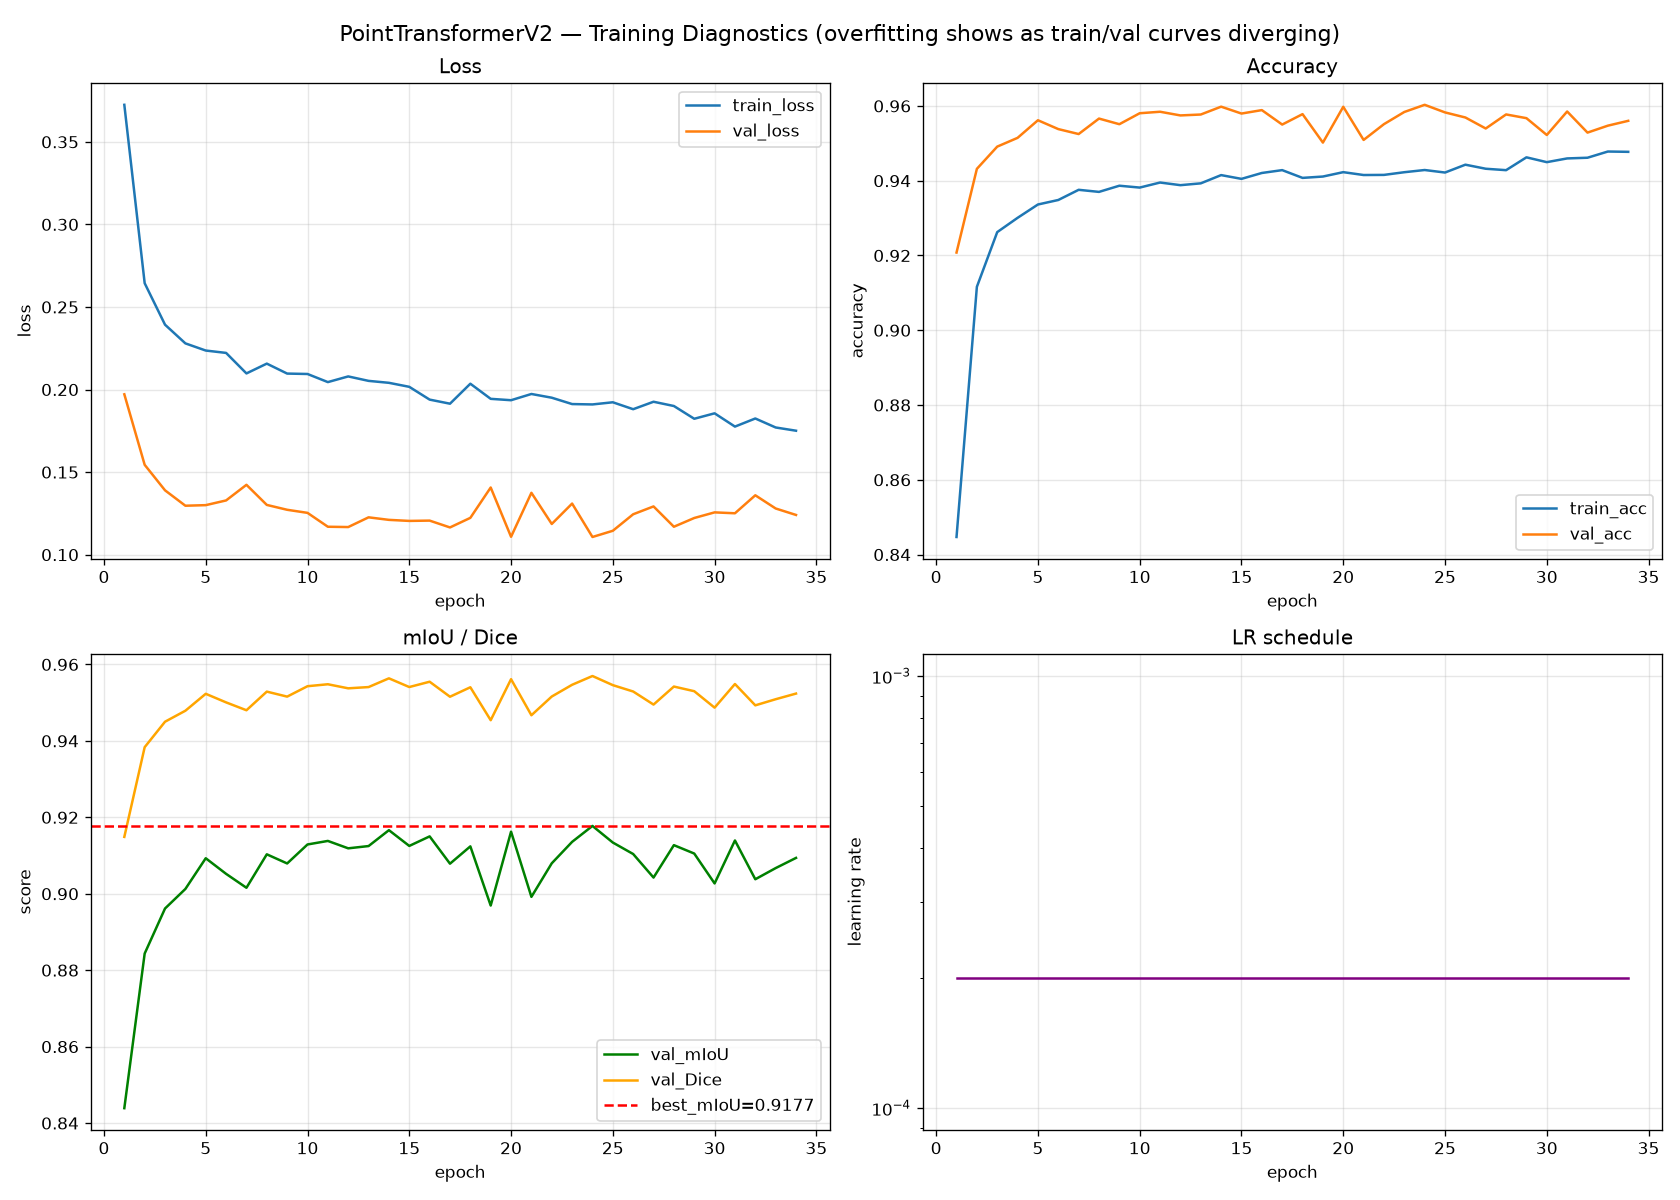

2026-07-23 04:48:17,443 | INFO | Loaded best model (mIoU=0.9177) from checkpoints/PT_v2_17_channel_v57_6_layer_fold0/PointTransformerV2_best.pth


🏃 View run PointTransformerV2_seg at: http://localhost:5000/#/experiments/11/runs/5f3368753dd14a4085445cee66237870
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 04:48:17,548 | INFO | Fold 1 best val mIoU: 0.9177
2026-07-23 04:48:17,548 | INFO | 
=== FOLD 2/5 ===
2026-07-23 04:48:17,694 | WARNING |   debug_anomaly_detection is ON — training will be much slower, but the exact operation producing NaN/Inf will be shown in the traceback the moment it happens
2026-07-23 04:48:17,717 | INFO | Using class weights: [1.2624233414321764, 0.7375766585678238]
2026-07-23 04:48:17,717 | INFO | No checkpoint found — training from scratch.
2026-07-23 04:48:37,467 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 04:48:38,491 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 04:50:02,189 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-2

🏃 View run epoch_0001 at: http://localhost:5000/#/experiments/11/runs/71c49aeeae254729a4c483f6eaf326d2
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 05:01:05,321 | INFO |   extra val metrics | Precision: 0.9636 | Recall: 0.9527 | F1: 0.9581 | ROC-AUC: 0.9889 | PR-AUC: 0.9931
2026-07-23 05:01:05,321 | INFO | Epoch   2/50 | Train Loss: 0.2629 | Val Loss: 0.1325 | Train Acc: 0.9100 | Val Acc: 0.9492 | mIoU: 0.8991 | Dice: 0.9467


...

🏃 View run epoch_0024 at: http://localhost:5000/#/experiments/11/runs/50d21e67d3e2480487c60a7542f4e8f4
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 07:18:44,419 | WARNING |   epoch 25: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 07:19:29,085 | WARNING |   epoch 25: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 07:21:23,274 | INFO |   extra val metrics | Precision: 0.9739 | Recall: 0.9606 | F1: 0.9672 | ROC-AUC: 0.9929 | PR-AUC: 0.9956
2026-07-23 07:21:23,274 | INFO | Epoch  25/50 | Train Loss: 0.1831 | Val Loss: 0.1034 | Train Acc: 0.9453 | Val Acc: 0.9602 | mIoU: 0.9201 | Dice: 0.9583


🏃 View run epoch_0025 at: http://localhost:5000/#/experiments/11/runs/85cb6ca396d9424c9e40e9e927ebc1b9
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 07:27:29,571 | INFO |   extra val metrics | Precision: 0.9760 | Recall: 0.9509 | F1: 0.9633 | ROC-AUC: 0.9913 | PR-AUC: 0.9945
2026-07-23 07:27:29,572 | INFO | Epoch  26/50 | Train Loss: 0.1870 | Val Loss: 0.1197 | Train Acc: 0.9451 | Val Acc: 0.9558 | mIoU: 0.9119 | Dice: 0.9538
2026-07-23 07:27:29,882 | INFO | Early stop at epoch 26 (no improvement for 10 epochs)


🏃 View run epoch_0026 at: http://localhost:5000/#/experiments/11/runs/ee9ab02152fc414a90abe5b380e88bd2
🧪 View experiment at: http://localhost:5000/#/experiments/11


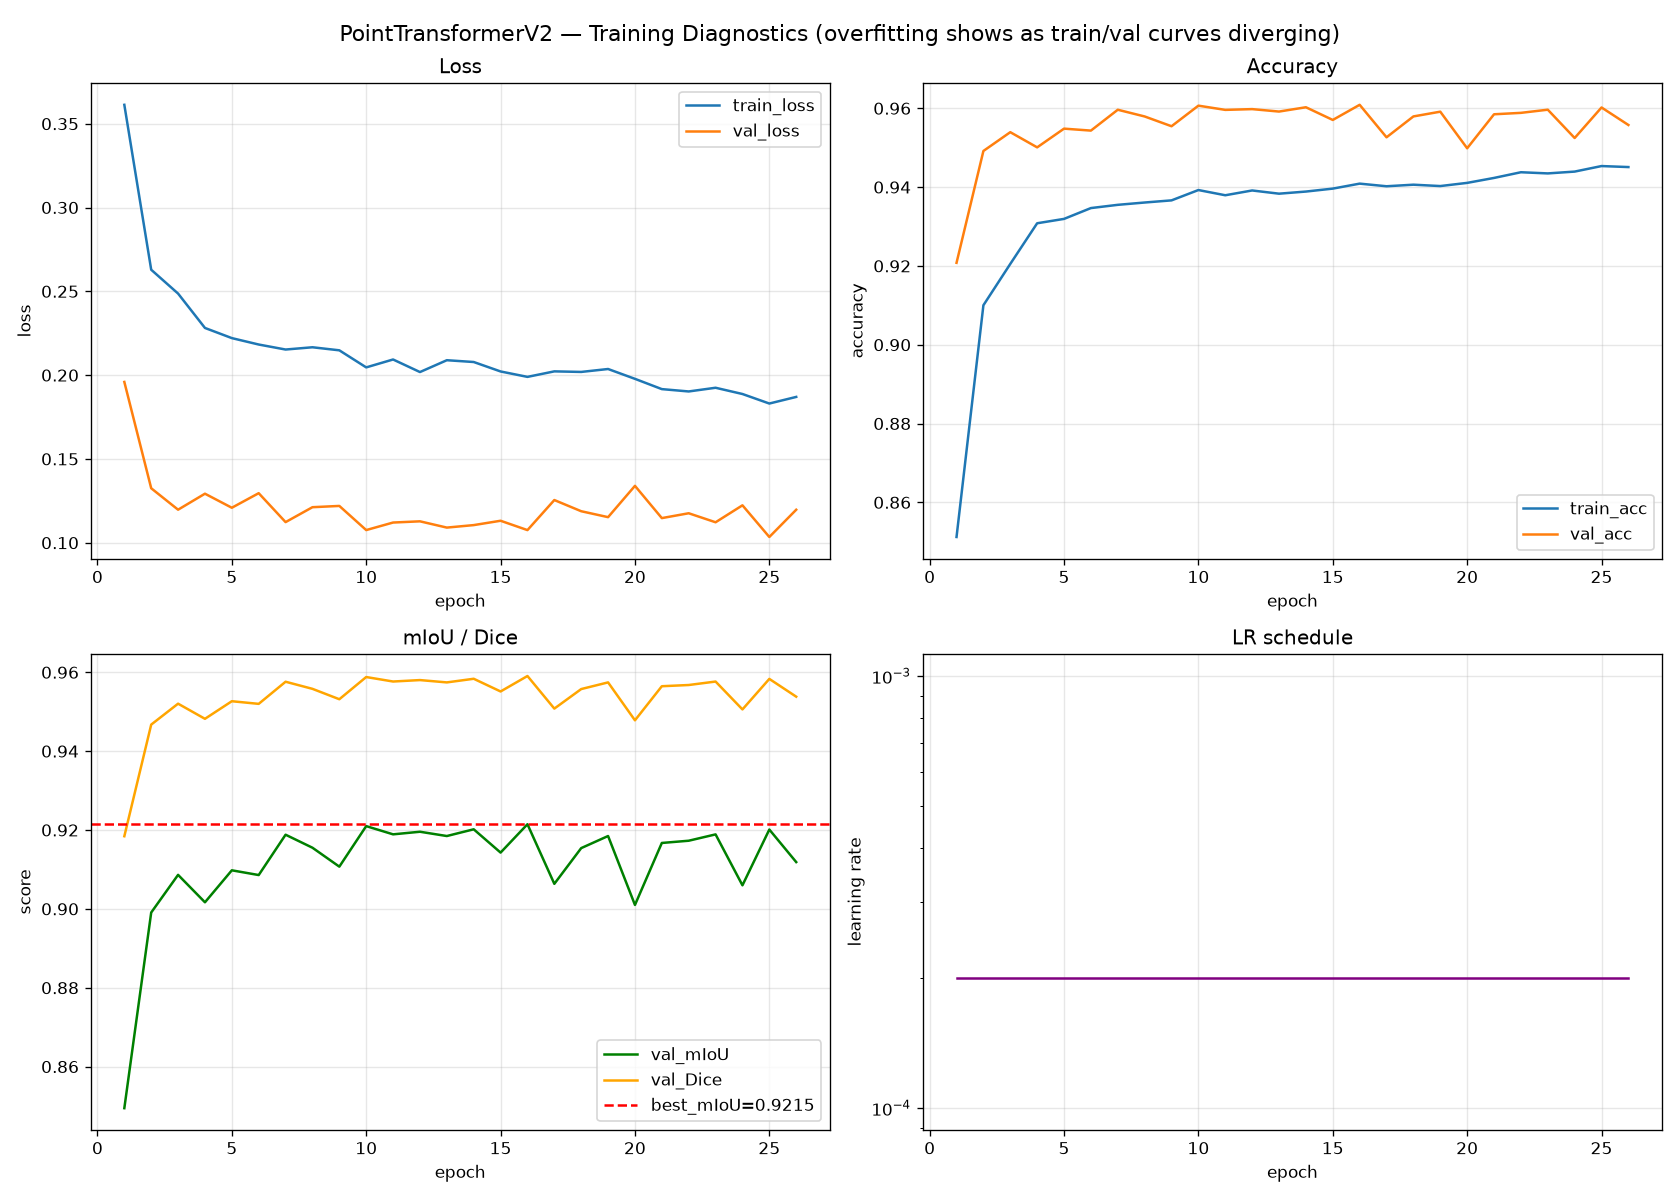

2026-07-23 07:27:30,686 | INFO | Loaded best model (mIoU=0.9215) from checkpoints/PT_v2_17_channel_v57_6_layer_fold1/PointTransformerV2_best.pth
2026-07-23 07:27:30,762 | INFO | Fold 2 best val mIoU: 0.9215
2026-07-23 07:27:30,763 | INFO | 
=== FOLD 3/5 ===


🏃 View run PointTransformerV2_seg at: http://localhost:5000/#/experiments/11/runs/2953da5cced240f592656fbc4a3eb7ee
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 07:27:30,918 | WARNING |   debug_anomaly_detection is ON — training will be much slower, but the exact operation producing NaN/Inf will be shown in the traceback the moment it happens
2026-07-23 07:27:30,939 | INFO | Using class weights: [1.2624233414321764, 0.7375766585678238]
2026-07-23 07:27:30,939 | INFO | No checkpoint found — training from scratch.
2026-07-23 07:27:50,537 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 07:28:17,759 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 07:30:09,558 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 07:30:15,710 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real par

🏃 View run epoch_0001 at: http://localhost:5000/#/experiments/11/runs/cdbadb83c7234fda9a7764763351a9a5
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 07:34:16,108 | INFO |   ✓ New best mIoU 0.7395 → saved checkpoints/PT_v2_17_channel_v57_6_layer_fold2/PointTransformerV2_best.pth
2026-07-23 07:40:22,197 | INFO |   extra val metrics | Precision: 0.8481 | Recall: 0.9468 | F1: 0.8948 | ROC-AUC: 0.9056 | PR-AUC: 0.8739
2026-07-23 07:40:22,197 | INFO | Epoch   2/50 | Train Loss: 0.1874 | Val Loss: 0.5436 | Train Acc: 0.9327 | Val Acc: 0.8735 | mIoU: 0.7678 | Dice: 0.8680


...

🏃 View run epoch_0023 at: http://localhost:5000/#/experiments/11/runs/7ab97a8771844f26b687a27c5f32086f
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 09:54:42,615 | INFO |   extra val metrics | Precision: 0.8597 | Recall: 0.9526 | F1: 0.9038 | ROC-AUC: 0.9147 | PR-AUC: 0.9054
2026-07-23 09:54:42,616 | INFO | Epoch  24/50 | Train Loss: 0.1074 | Val Loss: 0.6689 | Train Acc: 0.9632 | Val Acc: 0.8847 | mIoU: 0.7866 | Dice: 0.8801


🏃 View run epoch_0024 at: http://localhost:5000/#/experiments/11/runs/ef281450c8b84ae4a0f1540d9474ece7
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 09:59:39,178 | WARNING |   epoch 25: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 10:00:50,996 | INFO |   extra val metrics | Precision: 0.8566 | Recall: 0.9543 | F1: 0.9029 | ROC-AUC: 0.9107 | PR-AUC: 0.8962
2026-07-23 10:00:50,996 | INFO | Epoch  25/50 | Train Loss: 0.1039 | Val Loss: 0.6413 | Train Acc: 0.9635 | Val Acc: 0.8833 | mIoU: 0.7840 | Dice: 0.8784
2026-07-23 10:00:51,327 | INFO | Early stop at epoch 25 (no improvement for 10 epochs)


🏃 View run epoch_0025 at: http://localhost:5000/#/experiments/11/runs/bd471941248e42bab984c7fcc54b517b
🧪 View experiment at: http://localhost:5000/#/experiments/11


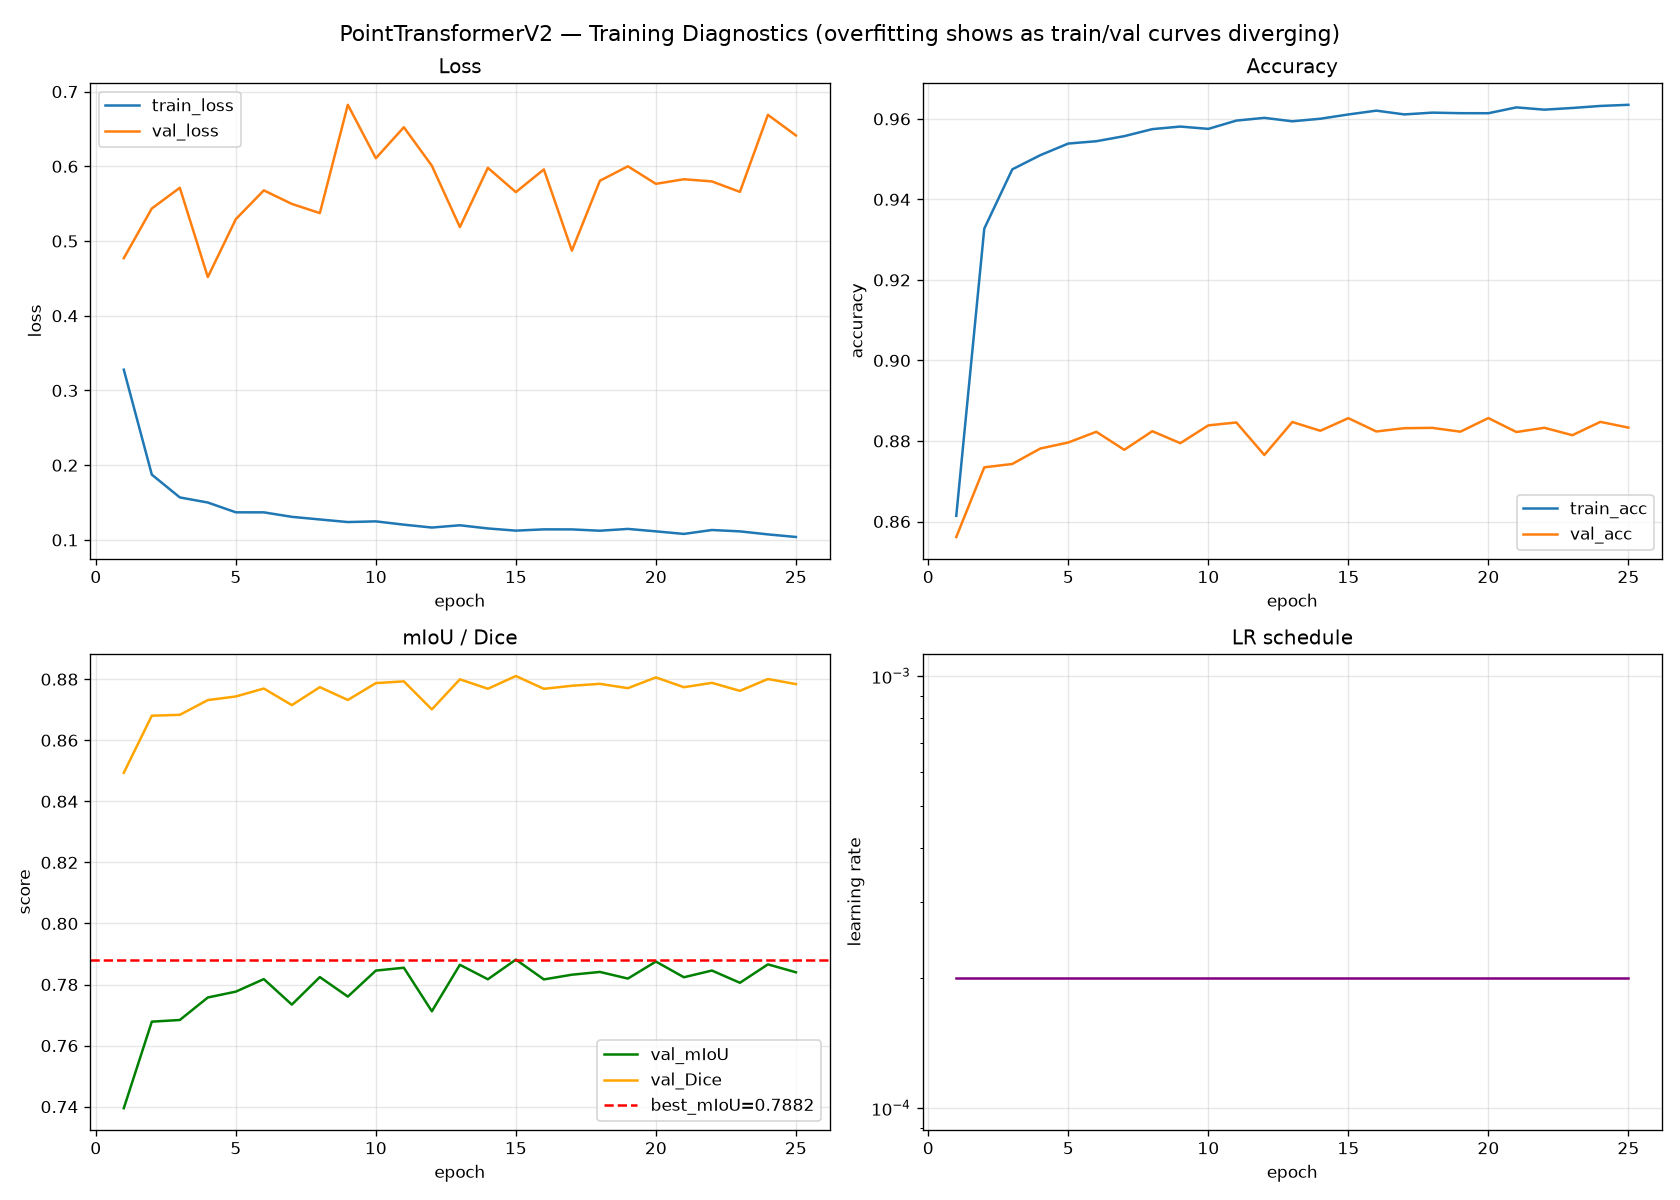

2026-07-23 10:00:52,016 | INFO | Loaded best model (mIoU=0.7882) from checkpoints/PT_v2_17_channel_v57_6_layer_fold2/PointTransformerV2_best.pth
2026-07-23 10:00:52,083 | INFO | Fold 3 best val mIoU: 0.7882
2026-07-23 10:00:52,084 | INFO | 
=== FOLD 4/5 ===


🏃 View run PointTransformerV2_seg at: http://localhost:5000/#/experiments/11/runs/04050b0973e645d99062a0ccef95f119
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 10:00:52,483 | WARNING |   debug_anomaly_detection is ON — training will be much slower, but the exact operation producing NaN/Inf will be shown in the traceback the moment it happens
2026-07-23 10:00:52,503 | INFO | Using class weights: [1.2624233414321764, 0.7375766585678238]
2026-07-23 10:00:52,504 | INFO | No checkpoint found — training from scratch.
2026-07-23 10:01:23,032 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 10:01:39,687 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 10:01:40,723 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 10:01:56,102 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real par

🏃 View run epoch_0001 at: http://localhost:5000/#/experiments/11/runs/2435c5a5468b4499bec2dc2c8d51ab9e
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 10:13:08,454 | INFO |   extra val metrics | Precision: 0.9605 | Recall: 0.9384 | F1: 0.9493 | ROC-AUC: 0.9790 | PR-AUC: 0.9817
2026-07-23 10:13:08,454 | INFO | Epoch   2/50 | Train Loss: 0.2518 | Val Loss: 0.1642 | Train Acc: 0.9185 | Val Acc: 0.9401 | mIoU: 0.8836 | Dice: 0.9381


...

🏃 View run epoch_0033 at: http://localhost:5000/#/experiments/11/runs/48ae57199a1b4201a2f7db880b6e21e4
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 13:29:17,442 | INFO |   extra val metrics | Precision: 0.9327 | Recall: 0.9803 | F1: 0.9559 | ROC-AUC: 0.9821 | PR-AUC: 0.9853
2026-07-23 13:29:17,442 | INFO | Epoch  34/50 | Train Loss: 0.1636 | Val Loss: 0.2004 | Train Acc: 0.9504 | Val Acc: 0.9460 | mIoU: 0.8926 | Dice: 0.9431


🏃 View run epoch_0034 at: http://localhost:5000/#/experiments/11/runs/fe77490029384e56acd38e793f3e7a2c
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 13:29:19,409 | WARNING |   epoch 35: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 13:35:28,386 | INFO |   extra val metrics | Precision: 0.9521 | Recall: 0.9737 | F1: 0.9628 | ROC-AUC: 0.9831 | PR-AUC: 0.9855
2026-07-23 13:35:28,386 | INFO | Epoch  35/50 | Train Loss: 0.1587 | Val Loss: 0.1798 | Train Acc: 0.9523 | Val Acc: 0.9550 | mIoU: 0.9103 | Dice: 0.9530
2026-07-23 13:35:28,736 | INFO | Early stop at epoch 35 (no improvement for 10 epochs)


🏃 View run epoch_0035 at: http://localhost:5000/#/experiments/11/runs/6b488f07cf1044d08b838b375f128c7d
🧪 View experiment at: http://localhost:5000/#/experiments/11


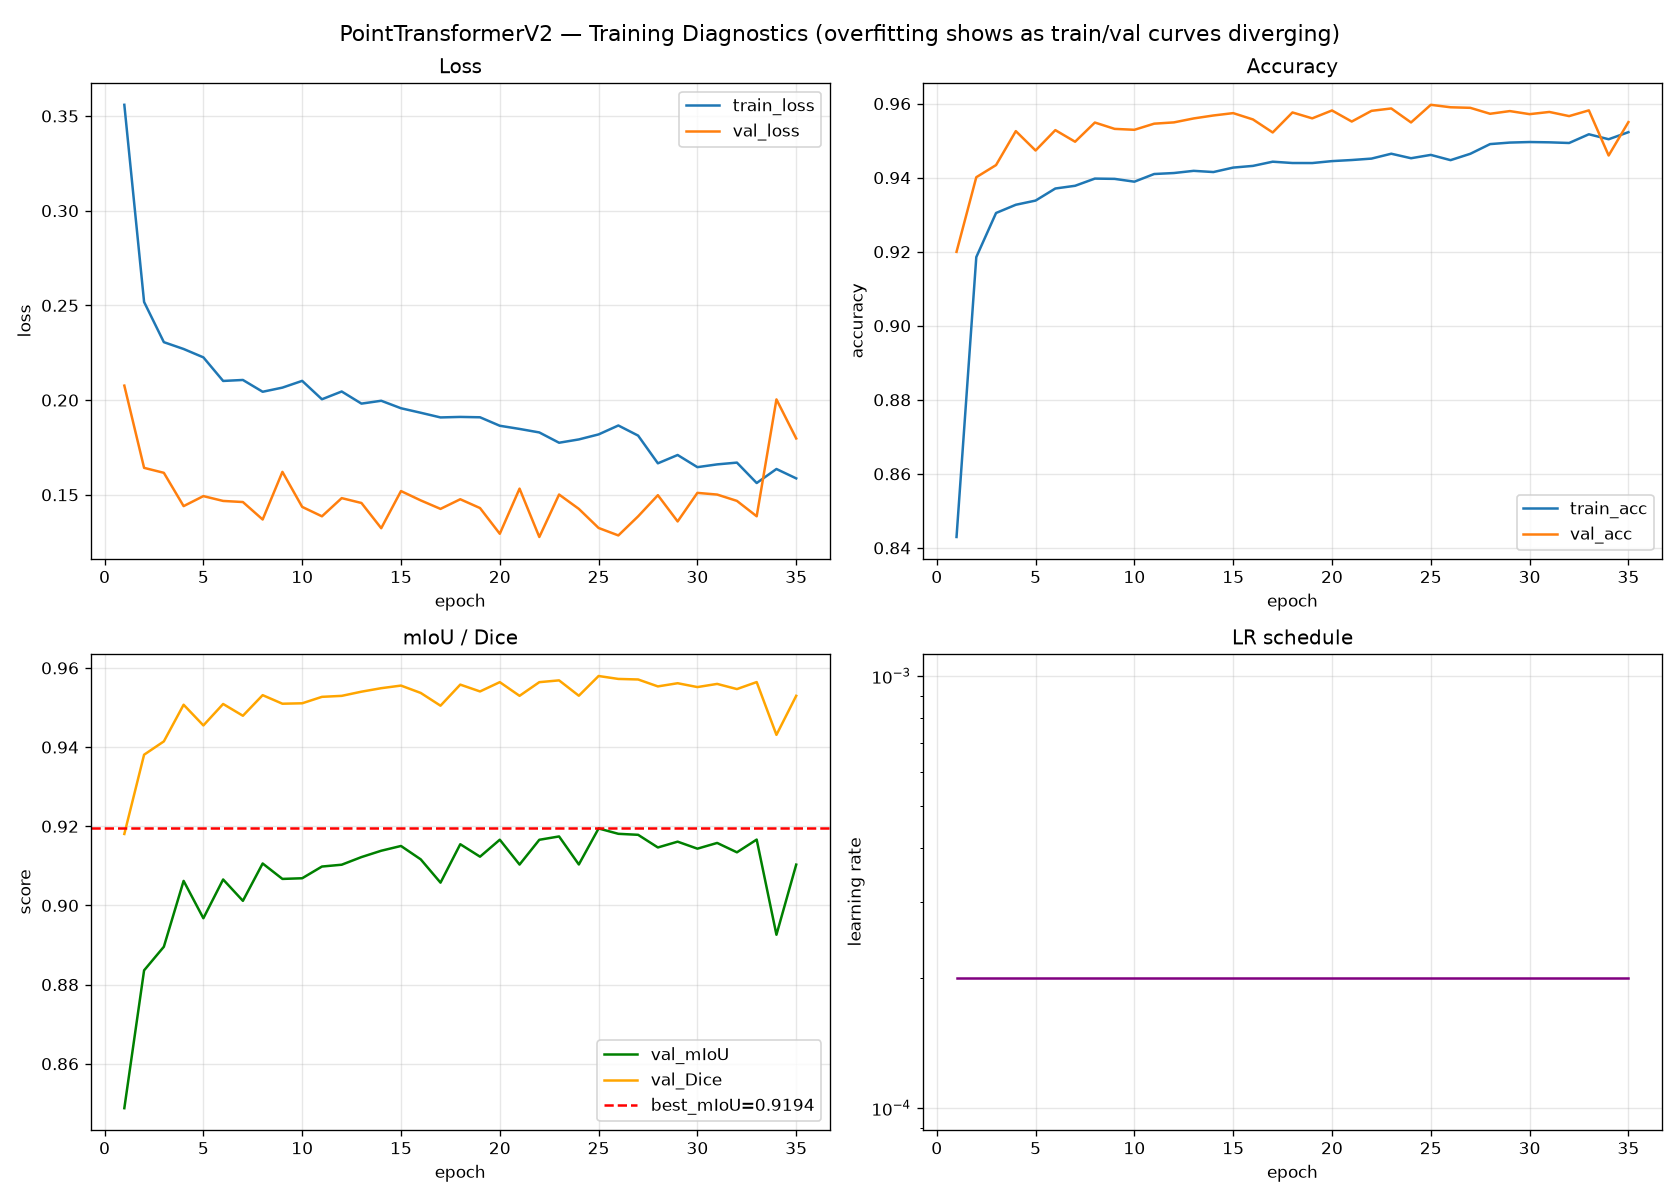

2026-07-23 13:35:29,408 | INFO | Loaded best model (mIoU=0.9194) from checkpoints/PT_v2_17_channel_v57_6_layer_fold3/PointTransformerV2_best.pth
2026-07-23 13:35:29,460 | INFO | Fold 4 best val mIoU: 0.9194
2026-07-23 13:35:29,461 | INFO | 
=== FOLD 5/5 ===


🏃 View run PointTransformerV2_seg at: http://localhost:5000/#/experiments/11/runs/2243756fc54f456da421e6ffde45d439
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 13:35:29,630 | WARNING |   debug_anomaly_detection is ON — training will be much slower, but the exact operation producing NaN/Inf will be shown in the traceback the moment it happens
2026-07-23 13:35:29,651 | INFO | Using class weights: [1.2624233414321764, 0.7375766585678238]
2026-07-23 13:35:29,652 | INFO | No checkpoint found — training from scratch.
2026-07-23 13:36:02,793 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 13:36:44,804 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 13:37:24,061 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 13:37:41,415 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real par

🏃 View run epoch_0001 at: http://localhost:5000/#/experiments/11/runs/d7c19de02dee4248be93c387dc55efa9
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 13:42:24,305 | INFO |   ✓ New best mIoU 0.8350 → saved checkpoints/PT_v2_17_channel_v57_6_layer_fold4/PointTransformerV2_best.pth
2026-07-23 13:48:40,912 | INFO |   extra val metrics | Precision: 0.9577 | Recall: 0.9318 | F1: 0.9446 | ROC-AUC: 0.9814 | PR-AUC: 0.9864
2026-07-23 13:48:40,912 | INFO | Epoch   2/50 | Train Loss: 0.2537 | Val Loss: 0.1668 | Train Acc: 0.9163 | Val Acc: 0.9343 | mIoU: 0.8728 | Dice: 0.9320


...

🏃 View run epoch_0044 at: http://localhost:5000/#/experiments/11/runs/ba60ea42f2c44d97be0eb75db34444ff
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 18:15:03,525 | WARNING |   epoch 45: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 18:15:40,984 | WARNING |   epoch 45: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-23 18:18:15,087 | INFO |   extra val metrics | Precision: 0.9566 | Recall: 0.9626 | F1: 0.9596 | ROC-AUC: 0.9824 | PR-AUC: 0.9844
2026-07-23 18:18:15,088 | INFO | Epoch  45/50 | Train Loss: 0.1429 | Val Loss: 0.1934 | Train Acc: 0.9548 | Val Acc: 0.9513 | mIoU: 0.9035 | Dice: 0.9492


🏃 View run epoch_0045 at: http://localhost:5000/#/experiments/11/runs/c18683cfd5054b8189671bfef5035c77
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 18:24:28,980 | INFO |   extra val metrics | Precision: 0.9496 | Recall: 0.9455 | F1: 0.9476 | ROC-AUC: 0.9769 | PR-AUC: 0.9819
2026-07-23 18:24:28,980 | INFO | Epoch  46/50 | Train Loss: 0.1352 | Val Loss: 0.2189 | Train Acc: 0.9566 | Val Acc: 0.9371 | mIoU: 0.8774 | Dice: 0.9346
2026-07-23 18:24:29,281 | INFO | Early stop at epoch 46 (no improvement for 10 epochs)


🏃 View run epoch_0046 at: http://localhost:5000/#/experiments/11/runs/ba22e6bfef614adfb24403f366679c56
🧪 View experiment at: http://localhost:5000/#/experiments/11


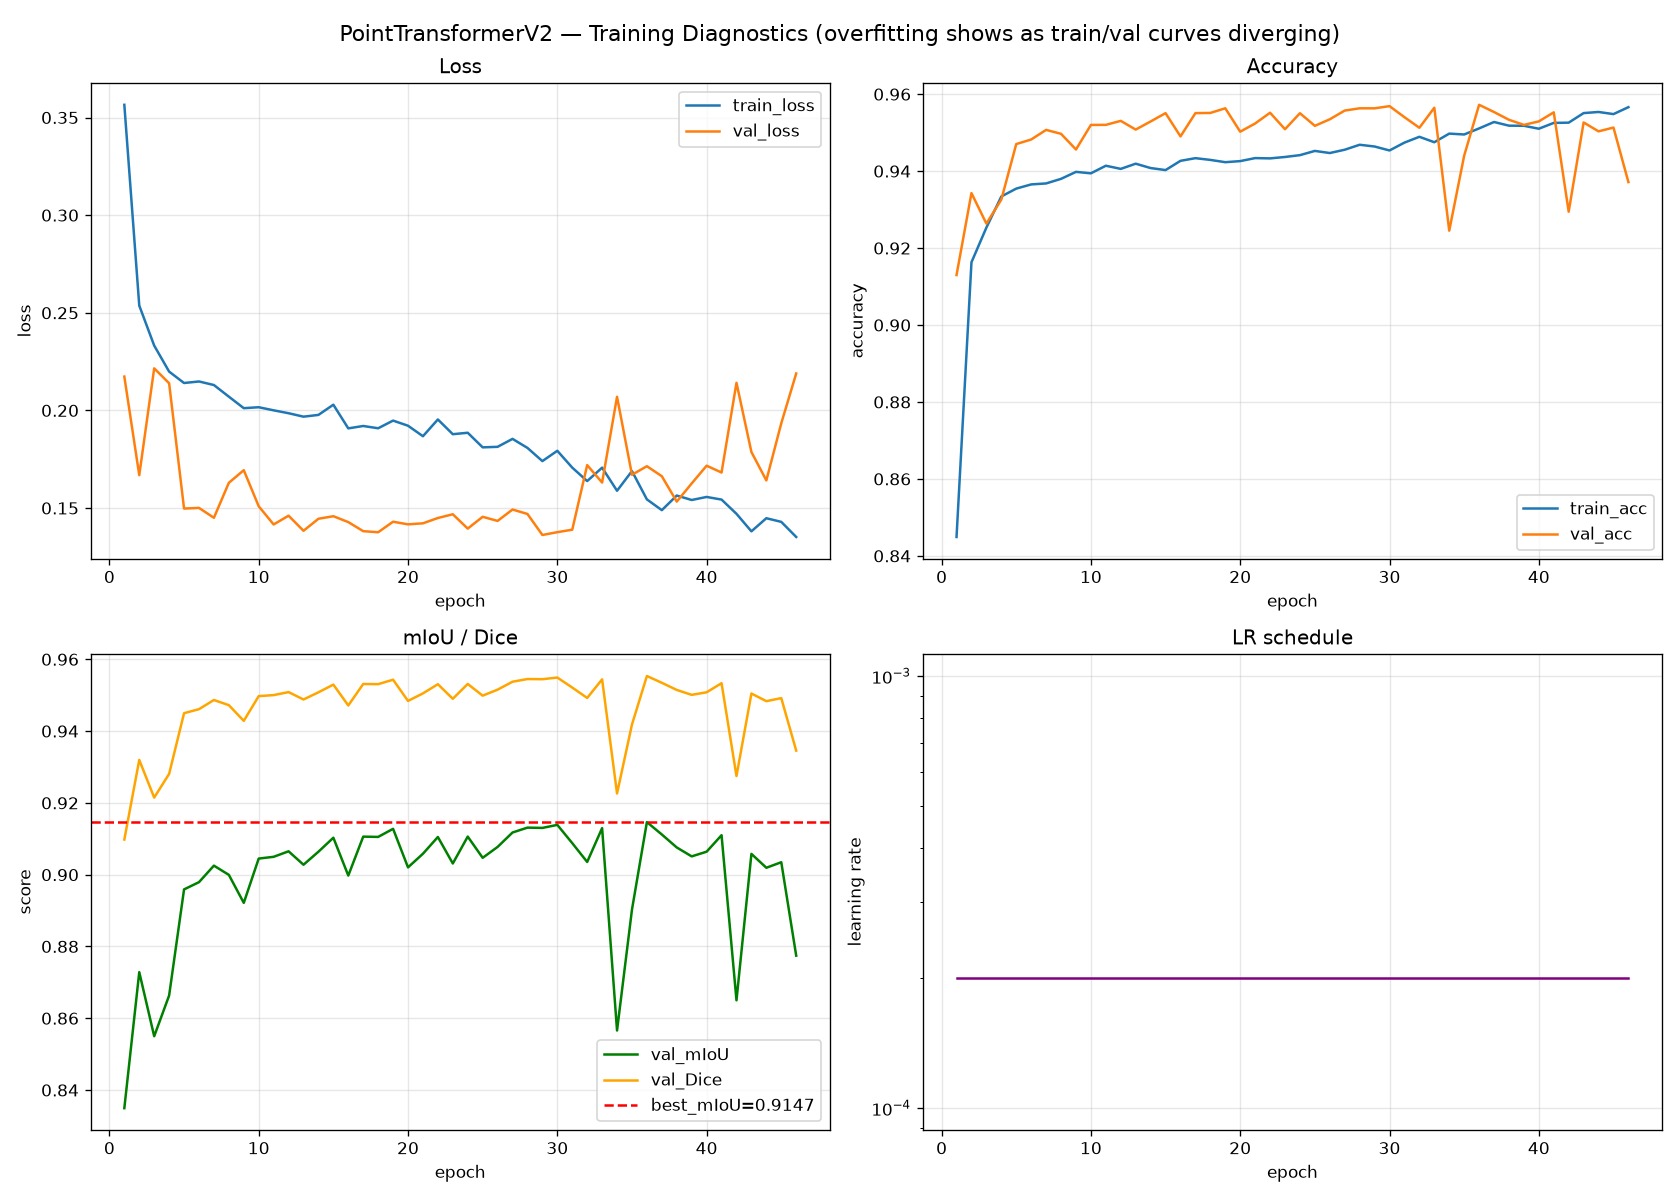

2026-07-23 18:24:30,005 | INFO | Loaded best model (mIoU=0.9147) from checkpoints/PT_v2_17_channel_v57_6_layer_fold4/PointTransformerV2_best.pth


🏃 View run PointTransformerV2_seg at: http://localhost:5000/#/experiments/11/runs/ce3ab46701d44c5990ed2089dd42e2ae
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 18:24:30,092 | INFO | Fold 5 best val mIoU: 0.9147
2026-07-23 18:24:30,092 | INFO | 
2026-07-23 18:24:30,092 | INFO | K-FOLD CV RESULTS (5 folds)
2026-07-23 18:24:30,093 | INFO |   per-fold mIoU: ['0.9177', '0.9215', '0.7882', '0.9194', '0.9147']
2026-07-23 18:24:30,093 | INFO |   mean ± std   : 0.8923 ± 0.0521
2026-07-23 18:24:30,093 | INFO | ============================================================
2026-07-23 18:24:30,663 | INFO | Loaded fold 2's weights (best mIoU=0.9215) into `model` for downstream use


In [13]:
if CV_FOLDS is None:
    model = train_model(model, MODEL_NAME)
else:
    _base_ckpt_dir = CONFIG["checkpoint_dir"]
    fold_mious = []
    for fold_idx, (TRAIN_FILES, VAL_FILES) in enumerate(CV_FOLDS):
        log.info(f"\n{'='*60}\n=== FOLD {fold_idx + 1}/{len(CV_FOLDS)} ===\n{'='*60}")
        CONFIG["checkpoint_dir"] = f"{_base_ckpt_dir}_fold{fold_idx}"
        os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
        model = build_model()
        model = train_model(model, MODEL_NAME)
        best_path = os.path.join(CONFIG["checkpoint_dir"], f"{MODEL_NAME}_best.pth")
        ckpt = torch.load(best_path, map_location="cpu", weights_only=False)
        fold_miou = ckpt.get("best_val_miou", float("nan"))
        fold_mious.append(fold_miou)
        log.info(f"Fold {fold_idx + 1} best val mIoU: {fold_miou:.4f}")
    CONFIG["checkpoint_dir"] = _base_ckpt_dir
    fold_mious = np.array(fold_mious)
    log.info(f"\n{'='*60}")
    log.info(f"K-FOLD CV RESULTS ({CONFIG['cv_folds']} folds)")
    log.info(f"  per-fold mIoU: {[f'{m:.4f}' for m in fold_mious]}")
    log.info(f"  mean ± std   : {fold_mious.mean():.4f} ± {fold_mious.std():.4f}")
    log.info(f"{'='*60}")
    best_fold = int(np.argmax(fold_mious))
    best_fold_path = os.path.join(f"{_base_ckpt_dir}_fold{best_fold+1}",
                                  f"{MODEL_NAME}_best.pth")
    state = torch.load(best_fold_path, map_location="cpu", weights_only=False)
    model = build_model()
    model.load_state_dict(state["model_state"])
    log.info(f"Loaded fold {best_fold + 1}'s weights (best mIoU="
             f"{fold_mious[best_fold]:.4f}) into `model` for downstream use")

## Visualization helper

In [14]:
def visualize_segmentation(points, predictions, title="Segmentation"):
    colors = np.zeros((len(points), 3), dtype=np.float64)
    colors[predictions == CONFIG["target_class"]] = [0.0, 0.8, 0.0]
    colors[predictions != CONFIG["target_class"]] = [0.8, 0.0, 0.0]
    pcd = o3d.geometry.PointCloud()
    center = points.mean(axis=0)
    pcd.points = o3d.utility.Vector3dVector(
        (points - center).astype(np.float64))
    pcd.colors = o3d.utility.Vector3dVector(colors)
    span = float((points.max(0) - points.min(0)).max()) * 0.5
    axes = o3d.geometry.TriangleMesh.create_coordinate_frame(size=span)
    n_target = int((predictions == CONFIG["target_class"]).sum())
    n_other  = len(predictions) - n_target
    full_title = (f"{title}  |  green(target)={n_target:,}  "
                  f"red(others)={n_other:,}")
    # o3d.visualization.draw_geometries([pcd, axes],
    #                                    window_name=full_title,
    #                                    width=1280, height=800)

## Inference helper

In [15]:
from scipy.spatial import cKDTree as _InferKDTree
@torch.no_grad()
def predict_full_cloud(model, path, overlap_factor=2):
    model.eval()
    pts, feat, lbl = get_features(path)
    n = len(feat)
    N = CONFIG["num_points"]
    B = CONFIG["batch_size"]
    log.info(f"predict_full_cloud: {n:,} points, N={N:,}/chunk, batch={B}, "
             f"device={DEVICE} — this can take a while on CPU, progress below")
    model.to(DEVICE)
    if n <= N:
        pad_idx = np.random.RandomState(0).choice(n, N, replace=True)
        x   = torch.from_numpy(feat[pad_idx][None].transpose(0, 2, 1)).to(DEVICE)
        out = model(x).argmax(dim=1).cpu().numpy().ravel()
        preds = np.zeros(n, np.int64)
        preds[pad_idx] = out
        model.to("cpu")
        return pts, preds, lbl
    tree      = _InferKDTree(feat[:, :3])
    covered   = np.zeros(n, bool)
    vote_sum  = np.zeros((n, NUM_CLASSES), np.int32)
    rng       = np.random.RandomState(0)
    batch_ids = []
    flush_count = 0
    def flush():
        nonlocal flush_count
        if not batch_ids:
            return
        x   = torch.from_numpy(
                  feat[np.stack(batch_ids)].transpose(0, 2, 1)).to(DEVICE)
        out = model(x).argmax(dim=1).cpu().numpy()
        for ids, o in zip(batch_ids, out):
            np.add.at(vote_sum, (ids, o), 1)
        batch_ids.clear()
        flush_count += 1
        pct = covered.mean() * 100
        log.info(f"  flush {flush_count}: {covered.sum():,}/{n:,} pts "
                 f"covered ({pct:.1f}%)")
        import sys; sys.stdout.flush()
    target_visits = max(1, overlap_factor)
    visit_count = np.zeros(n, np.int32)
    max_iters = int(np.ceil(n / N * target_visits)) + 4
    for _ in range(max_iters):
        if (visit_count >= target_visits).all():
            break
        least = np.flatnonzero(visit_count == visit_count.min())
        seed  = least[rng.randint(len(least))]
        _, idx = tree.query(pts[seed], k=N)
        idx = np.atleast_1d(idx)
        batch_ids.append(idx)
        visit_count[idx] += 1
        covered[idx] = True
        if len(batch_ids) == B:
            flush()
    flush()
    if not covered.all() and covered.any():
        missing     = np.flatnonzero(~covered)
        covered_idx = np.flatnonzero(covered)
        _, nn_local = _InferKDTree(pts[covered_idx]).query(pts[missing], k=1)
        vote_sum[missing] = vote_sum[covered_idx[nn_local]]
    preds = vote_sum.argmax(axis=1).astype(np.int64)
    model.to("cpu")
    return pts, preds, lbl

In [ ]:
# ── Save a consolidated, clearly-named copy of the overall-best checkpoint ──
# (only relevant when K-fold CV was used above; safe to skip otherwise)
if CV_FOLDS is not None:
    overall_best_path = f"{_base_ckpt_dir}_BEST_OVERALL.pth"
    state["source_fold"] = best_fold
    state["source_fold_miou"] = float(fold_mious[best_fold])
    state["all_fold_mious"] = fold_mious.tolist()
    torch.save(state, overall_best_path)
    log.info(f"  Saved consolidated best-overall checkpoint -> {overall_best_path} "
             f"(from fold {best_fold + 1}, mIoU={fold_mious[best_fold]:.4f})")
else:
    log.info("  CV_FOLDS is None (single training run) — no consolidated "
             "best-overall checkpoint needed; use the run's own best.pth")

## Per-file Train/Val Report (log only, no saving)

In [16]:
log.info("=== TRAIN/VAL PER-FILE REPORT ===")
trval_names, trval_true, trval_pred = [], [], []
for path in TRAIN_FILES:
    name = os.path.splitext(os.path.basename(path))[0]
    pts, preds, lbl = predict_full_cloud(model, path)
    trval_names.append(f"{name} [train]"); trval_true.append(lbl); trval_pred.append(preds)
per_file_report(trval_names, trval_true, trval_pred, tag="TRAIN",
                target_class=CONFIG["target_class"])
val_names, val_true, val_pred = [], [], []
for path in VAL_FILES:
    name = os.path.splitext(os.path.basename(path))[0]
    pts, preds, lbl = predict_full_cloud(model, path)
    val_names.append(f"{name} [val]"); val_true.append(lbl); val_pred.append(preds)
per_file_report(val_names, val_true, val_pred, tag="VAL",
                target_class=CONFIG["target_class"])

2026-07-23 18:24:30,695 | INFO | === TRAIN/VAL PER-FILE REPORT ===
2026-07-23 18:24:30,696 | INFO | predict_full_cloud: 311,676 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below
2026-07-23 18:24:31,120 | INFO |   flush 1: 8,192/311,676 pts covered (2.6%)
2026-07-23 18:24:31,457 | INFO |   flush 2: 8,192/311,676 pts covered (2.6%)
2026-07-23 18:24:31,800 | INFO |   flush 3: 8,192/311,676 pts covered (2.6%)
2026-07-23 18:24:32,134 | INFO |   flush 4: 8,192/311,676 pts covered (2.6%)
2026-07-23 18:24:32,485 | INFO |   flush 5: 8,192/311,676 pts covered (2.6%)
2026-07-23 18:24:32,838 | INFO |   flush 6: 8,192/311,676 pts covered (2.6%)
2026-07-23 18:24:33,172 | INFO |   flush 7: 8,192/311,676 pts covered (2.6%)
2026-07-23 18:24:33,524 | INFO |   flush 8: 8,192/311,676 pts covered (2.6%)
2026-07-23 18:24:33,859 | INFO |   flush 9: 8,192/311,676 pts covered (2.6%)
2026-07-23 18:24:34,193 | INFO |   flush 10: 8,192/311,676 pts covered (2.6%)
2026-07-23


PER-FILE SEGMENTATION REPORT — TRAIN
File                      IoU   Dice   Prec    Rec       TP       FP       FN       TN   GT_Wood  Pred_Wood
-----------------------------------------------------------------------------------------------------------
sample_data_0013 [train]  0.034  0.067  0.876  0.035    7,210    1,022  201,157  102,287   208,367      8,232
sample_data_0020 [train]  0.001  0.001  0.995  0.001      192        1  284,551  135,832   284,743        193
sample_data_0017 [train]  0.000  0.000  1.000  0.000        1        0  387,123  169,275   387,124          1
sample_data_0012 [train]  0.000  0.000  0.000  0.000        0      100  240,600  159,505   240,600        100
sample_data_0015 [train]  0.001  0.001  0.771  0.001      148       44  278,466  112,710   278,614        192
sample_data_0031 [train]  0.504  0.670  0.940  0.520  107,040    6,799   98,664   23,836   205,704    113,839
sample_data_0039 [train]  0.066  0.123  0.970  0.066   13,919      433  197,291   85,1

2026-07-23 18:29:06,944 | INFO |   flush 1: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:07,219 | INFO |   flush 2: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:07,493 | INFO |   flush 3: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:07,767 | INFO |   flush 4: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:08,042 | INFO |   flush 5: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:08,315 | INFO |   flush 6: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:08,587 | INFO |   flush 7: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:08,860 | INFO |   flush 8: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:09,134 | INFO |   flush 9: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:09,408 | INFO |   flush 10: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:09,683 | INFO |   flush 11: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:09,957 | INFO |   flush 12: 8,192/450,029 pts covered (1.8%)
2026-07-23 18:29:10,230 | INFO |   flush 13: 8,192/450,029 pts covered (1


PER-FILE SEGMENTATION REPORT — VAL
File                      IoU   Dice   Prec    Rec       TP       FP       FN       TN   GT_Wood  Pred_Wood
-----------------------------------------------------------------------------------------------------------
sample_data_0027 [val]  0.034  0.066  0.854  0.034    8,760    1,495  247,753  192,021   256,513     10,255
sample_data_0043 [val]  0.000  0.000  0.000  0.000        0        0  267,275  178,529   267,275          0
sample_data_0037 [val]  0.068  0.127  0.946  0.068   27,218    1,566  372,335  131,658   399,553     28,784
sample_data_0014 [val]  0.000  0.000  0.000  0.000        0        0  224,868   94,193   224,868          0
sample_data_004 [val]   0.000  0.000  0.000  0.000        0        0  225,278  188,287   225,278          0
sample_data_0030 [val]  0.082  0.151  0.898  0.083   20,972    2,389  232,797  147,479   253,769     23,361
sample_data_0044 [val]  0.000  0.000  0.000  0.000        0        0  195,863  128,849   195,863    

In [17]:
from scipy.spatial import Delaunay, cKDTree
def sor_filter(pts, k=16, std_ratio=2.0):
    pts = np.asarray(pts, np.float64)
    if len(pts) <= k + 1:
        return pts, np.ones(len(pts), bool)
    tree = cKDTree(pts)
    d, _ = tree.query(pts, k=k + 1)
    mean_dist = d[:, 1:].mean(axis=1)
    thr  = mean_dist.mean() + std_ratio * mean_dist.std()
    mask = mean_dist <= thr
    return pts[mask], mask
def extract_main_cluster(pts, eps=0.15, min_samples=8):
    pts = np.asarray(pts, np.float64)
    if len(pts) < min_samples * 2:
        return pts
    try:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        labels = np.asarray(pcd.cluster_dbscan(eps=eps, min_points=min_samples))
        valid = labels[labels >= 0]
        if valid.size == 0:
            return pts
        main_lbl = np.bincount(valid).argmax()
        result = pts[labels == main_lbl]
        return result if len(result) >= min_samples else pts
    except Exception as e:
        log.warning(f"[TIN] cluster extraction failed ({e}) -> using all points")
        return pts
def tin_integrate(pts, floor_pct=0.5):
    pts = np.asarray(pts, np.float64)
    if len(pts) < 4:
        return float("nan")
    floor_z = np.percentile(pts[:, 2], floor_pct)
    h  = pts[:, 2] - floor_z
    xy = pts[:, :2]
    try:
        tri = Delaunay(xy)
    except Exception as e:
        log.warning(f"[TIN] Delaunay failed ({e})")
        return float("nan")
    t = tri.simplices
    p0, p1, p2 = xy[t[:, 0]], xy[t[:, 1]], xy[t[:, 2]]
    h0, h1, h2 = h[t[:, 0]], h[t[:, 1]], h[t[:, 2]]
    cross  = ((p1[:, 0] - p0[:, 0]) * (p2[:, 1] - p0[:, 1])
             - (p1[:, 1] - p0[:, 1]) * (p2[:, 0] - p0[:, 0]))
    area2d = np.abs(cross) / 2.0
    mean_h = (h0 + h1 + h2) / 3.0
    valid  = mean_h > 0
    return float(np.sum(area2d[valid] * mean_h[valid]))
def bootstrap_tin_confidence(pts, n_bootstrap=80, subsample_frac=0.85,
                             floor_pct=0.5, seed=0):
    rng = np.random.RandomState(seed)
    n = len(pts)
    n_sub = max(10, int(n * subsample_frac))
    estimates = []
    for _ in range(n_bootstrap):
        idx = rng.choice(n, n_sub, replace=False)
        v = tin_integrate(pts[idx], floor_pct=floor_pct)
        if np.isfinite(v) and v > 0:
            estimates.append(v)
    if len(estimates) < 5:
        return None
    arr = np.array(estimates)
    return {"std":     round(float(arr.std()), 5),
            "ci_low":  round(float(np.percentile(arr, 2.5)), 5),
            "ci_high": round(float(np.percentile(arr, 97.5)), 5)}
def vol_TIN(pts, sor_k=16, sor_std=2.0, cluster_eps=0.15,
            floor_pct=0.5, run_bootstrap=True, n_bootstrap=80):
    pts = np.asarray(pts, np.float64)
    if len(pts) < 10:
        return float("nan"), None
    pts, _ = sor_filter(pts, k=sor_k, std_ratio=sor_std)
    if len(pts) < 10:
        return float("nan"), None
    pts = extract_main_cluster(pts, eps=cluster_eps)
    if len(pts) < 10:
        return float("nan"), None
    volume = tin_integrate(pts, floor_pct=floor_pct)
    conf = None
    if run_bootstrap and len(pts) >= 20:
        conf = bootstrap_tin_confidence(pts, n_bootstrap=n_bootstrap,
                                        floor_pct=floor_pct)
    return float(volume), conf

## Testing  (held-out test files with labels)

2026-07-23 18:30:04,352 | INFO | === TESTING ===
2026-07-23 18:30:05,503 | INFO |   SOR: removed 5160 outlier pts (sample_data_0045.las)
2026-07-23 18:30:06,609 | INFO |   Cluster-filter: removed 1683 pts in small floating clusters (sample_data_0045.las)
2026-07-23 18:30:21,462 | INFO | predict_full_cloud: 416,144 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below
2026-07-23 18:30:21,782 | INFO |   flush 1: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:30:22,004 | INFO |   flush 2: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:30:22,229 | INFO |   flush 3: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:30:22,456 | INFO |   flush 4: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:30:22,683 | INFO |   flush 5: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:30:22,907 | INFO |   flush 6: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:30:23,133 | INFO |   flush 7: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:30:23,364 | INFO |   flush 8: 8,192/416,


PER-FILE SEGMENTATION REPORT — TEST
File                      IoU   Dice   Prec    Rec       TP       FP       FN       TN   GT_Wood  Pred_Wood
-----------------------------------------------------------------------------------------------------------
sample_data_0045        0.085  0.156  0.943  0.085   18,935    1,146  202,994  193,069   221,929     20,081
sample_data_0032        0.079  0.147  0.791  0.081   16,085    4,255  183,121  177,155   199,206     20,340
sample_data_0033        0.000  0.000  0.000  0.000        0        0  215,719  231,565   215,719          0
sample_data_008         0.000  0.000  0.000  0.000        0        0  282,945  161,187   282,945          0
sample_data_0041        0.131  0.231  0.872  0.133   29,564    4,322  192,299  139,916   221,863     33,886
sample_data_006         0.000  0.000  0.000  0.000        0      661  192,663  447,546   192,663        661
---------------------------------------------------------------------------------------------------

2026-07-23 18:32:45,523 | INFO | === TEST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  background       0.52      0.99      0.68   1360822
 wood_powder       0.86      0.05      0.09   1334325

    accuracy                           0.53   2695147
   macro avg       0.69      0.52      0.39   2695147
weighted avg       0.69      0.53      0.39   2695147



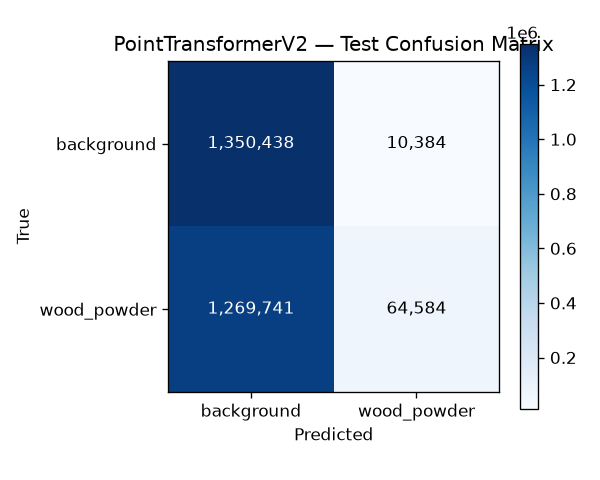

,file,iou,dice,precision,recall,tp,fp,fn,tn,gt_wood,pred_wood
0,sample_data_0045,0.0849,0.1565,0.9429,0.0853,18935,1146,202994,193069,221929,20081
1,sample_data_0032,0.0791,0.1465,0.7908,0.0807,16085,4255,183121,177155,199206,20340
2,sample_data_0033,0.0000,0.0000,0.0000,0.0000,0,0,215719,231565,215719,0
3,sample_data_008,0.0000,0.0000,0.0000,0.0000,0,0,282945,161187,282945,0
4,sample_data_0041,0.1307,0.2312,0.8725,0.1333,29564,4322,192299,139916,221863,33886
5,sample_data_006,0.0000,0.0000,0.0000,0.0000,0,661,192663,447546,192663,661


2026-07-23 18:32:46,233 | INFO | predict_full_cloud: 416,144 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below


🏃 View run PointTransformerV2_seg at: http://localhost:5000/#/experiments/11/runs/ce3ab46701d44c5990ed2089dd42e2ae
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 18:32:46,550 | INFO |   flush 1: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:46,770 | INFO |   flush 2: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:46,993 | INFO |   flush 3: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:47,217 | INFO |   flush 4: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:47,443 | INFO |   flush 5: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:47,669 | INFO |   flush 6: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:47,893 | INFO |   flush 7: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:48,116 | INFO |   flush 8: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:48,343 | INFO |   flush 9: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:48,571 | INFO |   flush 10: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:48,798 | INFO |   flush 11: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:49,023 | INFO |   flush 12: 8,192/416,144 pts covered (2.0%)
2026-07-23 18:32:49,248 | INFO |   flush 13: 8,192/416,144 pts covered (2


───────────────────────────────────────────────────────
  File          : sample_data_0045
  Total Points  : 416,144
  Target Points : 20,081
  Other Points  : 396,063
  Target Ratio  : 4.83%
  Est. Volume   : 0.8948 m³
  95% CI        : [0.8726 – 0.9361] m³  (±0.0161)
───────────────────────────────────────────────────────


...


───────────────────────────────────────────────────────
  File          : sample_data_0032
  Total Points  : 380,616
  Target Points : 20,340
  Other Points  : 360,276
  Target Ratio  : 5.34%
  Est. Volume   : 0.2422 m³
  95% CI        : [0.2316 – 0.2655] m³  (±0.0073)
───────────────────────────────────────────────────────


2026-07-23 18:33:02,796 | INFO | predict_full_cloud: 447,284 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below


🏃 View run PointTransformerV2_seg at: http://localhost:5000/#/experiments/11/runs/ce3ab46701d44c5990ed2089dd42e2ae
🧪 View experiment at: http://localhost:5000/#/experiments/11


2026-07-23 18:33:03,146 | INFO |   flush 1: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:03,400 | INFO |   flush 2: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:03,658 | INFO |   flush 3: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:03,913 | INFO |   flush 4: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:04,170 | INFO |   flush 5: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:04,426 | INFO |   flush 6: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:04,682 | INFO |   flush 7: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:04,935 | INFO |   flush 8: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:05,191 | INFO |   flush 9: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:05,449 | INFO |   flush 10: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:05,709 | INFO |   flush 11: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:05,966 | INFO |   flush 12: 8,192/447,284 pts covered (1.8%)
2026-07-23 18:33:06,231 | INFO |   flush 13: 8,192/447,284 pts covered (1


───────────────────────────────────────────────────────
  File          : sample_data_0033
  Total Points  : 447,284
  Target Points : 0
  Other Points  : 447,284
  Target Ratio  : 0.00%
  Est. Volume   : nan m³
───────────────────────────────────────────────────────
🏃 View run PointTransformerV2_seg at: http://localhost:5000/#/experiments/11/runs/ce3ab46701d44c5990ed2089dd42e2ae
🧪 View experiment at: http://localhost:5000/#/experiments/11


In [18]:
log.info("=== TESTING ===")
test_names, test_true, test_pred = [], [], []
for path in TEST_FILES:
    name = os.path.splitext(os.path.basename(path))[0]
    pts, preds, lbl = predict_full_cloud(model, path)
    test_names.append(name); test_true.append(lbl); test_pred.append(preds)
per_file_report(test_names, test_true, test_pred, tag="TEST",
                target_class=CONFIG["target_class"])

if MLFLOW_OK and test_true and all(t is not None for t in test_true):
    from sklearn.metrics import classification_report
    _all_true = np.concatenate(test_true)
    _all_pred = np.concatenate(test_pred)
    _report_dict = classification_report(
        _all_true, _all_pred, target_names=["background", "wood_powder"],
        output_dict=True, zero_division=0)
    _report_text = classification_report(
        _all_true, _all_pred, target_names=["background", "wood_powder"],
        zero_division=0)
    log.info("=== TEST CLASSIFICATION REPORT ===\n" + _report_text)

    _test_miou = compute_miou(_all_true, _all_pred, NUM_CLASSES)
    _test_dice = compute_dice(_all_true, _all_pred, NUM_CLASSES)

    try:
        with mlflow.start_run(run_id=LAST_RUN_ID):
            mlflow.log_metrics({
                "test_accuracy"          : _report_dict["accuracy"],
                "test_miou"              : _test_miou,
                "test_dice"              : _test_dice,
                "test_precision_target"  : _report_dict["wood_powder"]["precision"],
                "test_recall_target"     : _report_dict["wood_powder"]["recall"],
                "test_f1_target"         : _report_dict["wood_powder"]["f1-score"],
                "test_precision_bg"      : _report_dict["background"]["precision"],
                "test_recall_bg"         : _report_dict["background"]["recall"],
                "test_f1_bg"             : _report_dict["background"]["f1-score"],
            })
            _report_path = os.path.join(CONFIG["checkpoint_dir"],
                                        f"{MODEL_NAME}_test_classification_report.txt")
            with open(_report_path, "w") as _f:
                _f.write(_report_text)
            mlflow.log_artifact(_report_path)

            import matplotlib
            matplotlib.use("Agg")
            import matplotlib.pyplot as _plt2
            from sklearn.metrics import confusion_matrix
            _cm = confusion_matrix(_all_true, _all_pred, labels=list(range(NUM_CLASSES)))
            _fig_cm, _ax_cm = _plt2.subplots(figsize=(5, 4))
            _im = _ax_cm.imshow(_cm, cmap="Blues")
            _ax_cm.set_xticks(range(NUM_CLASSES)); _ax_cm.set_yticks(range(NUM_CLASSES))
            _ax_cm.set_xticklabels(["background", "wood_powder"])
            _ax_cm.set_yticklabels(["background", "wood_powder"])
            _ax_cm.set_xlabel("Predicted"); _ax_cm.set_ylabel("True")
            _ax_cm.set_title(f"{MODEL_NAME} — Test Confusion Matrix")
            for _r in range(NUM_CLASSES):
                for _c in range(NUM_CLASSES):
                    _ax_cm.text(_c, _r, f"{_cm[_r, _c]:,}", ha="center", va="center",
                              color="white" if _cm[_r, _c] > _cm.max() / 2 else "black")
            _plt2.colorbar(_im, ax=_ax_cm)
            _plt2.tight_layout()
            _cm_path = os.path.join(CONFIG["checkpoint_dir"], f"{MODEL_NAME}_confusion_matrix.png")
            _plt2.savefig(_cm_path, dpi=120)
            _plt2.close(_fig_cm)
            mlflow.log_artifact(_cm_path)
            from IPython.display import Image as _IPyImage2, display as _ipy_display2
            _ipy_display2(_IPyImage2(filename=_cm_path))

            import csv as _csv
            _csv_path = os.path.join(CONFIG["checkpoint_dir"], f"{MODEL_NAME}_per_file_test_report.csv")
            with open(_csv_path, "w", newline="") as _f:
                _w = _csv.writer(_f)
                _w.writerow(["file", "iou", "dice", "precision", "recall",
                           "tp", "fp", "fn", "tn", "gt_wood", "pred_wood"])
                for _name, _true, _pred in zip(test_names, test_true, test_pred):
                    if _true is None:
                        continue
                    _tp = int(((_true == CONFIG["target_class"]) &
                              (_pred == CONFIG["target_class"])).sum())
                    _fp = int(((_true != CONFIG["target_class"]) &
                              (_pred == CONFIG["target_class"])).sum())
                    _fn = int(((_true == CONFIG["target_class"]) &
                              (_pred != CONFIG["target_class"])).sum())
                    _tn = int(((_true != CONFIG["target_class"]) &
                              (_pred != CONFIG["target_class"])).sum())
                    _iou = _tp / (_tp + _fp + _fn) if (_tp + _fp + _fn) > 0 else 0.0
                    _dice_v = (2 * _tp / (2 * _tp + _fp + _fn)
                              if (2 * _tp + _fp + _fn) > 0 else 0.0)
                    _prec_v = _tp / (_tp + _fp) if (_tp + _fp) > 0 else 0.0
                    _rec_v = _tp / (_tp + _fn) if (_tp + _fn) > 0 else 0.0
                    _gt_wood = int((_true == CONFIG["target_class"]).sum())
                    _pred_wood = int((_pred == CONFIG["target_class"]).sum())
                    _w.writerow([_name, f"{_iou:.4f}", f"{_dice_v:.4f}", f"{_prec_v:.4f}",
                               f"{_rec_v:.4f}", _tp, _fp, _fn, _tn, _gt_wood, _pred_wood])
            mlflow.log_artifact(_csv_path)
            import pandas as _pd
            _ipy_display2(_pd.read_csv(_csv_path))
    except Exception as _e:
        log.warning(f"Could not log test metrics to MLflow (run_id={LAST_RUN_ID}): {_e}")
for path in TEST_FILES[:CONFIG["max_vis_files"]]:
    name = os.path.splitext(os.path.basename(path))[0]
    pts, preds, _ = predict_full_cloud(model, path)
    target_pts   = pts[preds == CONFIG["target_class"]]
    volume, conf = vol_TIN(target_pts)
    n_tot = len(pts)
    n_tgt = len(target_pts)
    print(f"\n{'─'*55}")
    print(f"  File          : {name}")
    print(f"  Total Points  : {n_tot:,}")
    print(f"  Target Points : {n_tgt:,}")
    print(f"  Other Points  : {n_tot - n_tgt:,}")
    print(f"  Target Ratio  : {n_tgt / max(n_tot, 1) * 100:.2f}%")
    print(f"  Est. Volume   : {volume:.4f} m³")
    if conf:
        print(f"  95% CI        : [{conf['ci_low']:.4f} – {conf['ci_high']:.4f}] m³"
              f"  (±{conf['std']:.4f})")
    print(f"{'─'*55}")
    visualize_segmentation(pts, preds,
                           title=f"{MODEL_NAME} | {name} | V={volume:.4f} m³")
    if MLFLOW_OK:
        try:
            import matplotlib
            matplotlib.use("Agg")
            import matplotlib.pyplot as _plt3
            _fig_s = _plt3.figure(figsize=(6, 5))
            _ax_s = _fig_s.add_subplot(111)
            _sub_idx = (np.random.RandomState(0).choice(len(pts), 20000, replace=False)
                       if len(pts) > 20000 else np.arange(len(pts)))
            _colors = np.where(preds[_sub_idx] == CONFIG["target_class"], "green", "red")
            _ax_s.scatter(pts[_sub_idx, 0], pts[_sub_idx, 1], c=_colors, s=1, alpha=0.5)
            _ax_s.set_title(f"{MODEL_NAME} | {name} (top-down view)")
            _ax_s.set_xlabel("X"); _ax_s.set_ylabel("Y"); _ax_s.set_aspect("equal")
            _plt3.tight_layout()
            _sample_path = os.path.join(CONFIG["checkpoint_dir"], f"{MODEL_NAME}_{name}_sample.png")
            _plt3.savefig(_sample_path, dpi=100)
            _plt3.close(_fig_s)
            with mlflow.start_run(run_id=LAST_RUN_ID):
                mlflow.log_artifact(_sample_path)
        except Exception as _e:
            log.warning(f"Could not log sample visualization for {name}: {_e}")

## Final Inference  (`data/test`, no labels)

In [19]:
if INFER_FILES:
    log.info("=== FINAL INFERENCE ===")
    infer_names, infer_true, infer_pred, infer_pts = [], [], [], []
    for path in INFER_FILES:
        name = os.path.splitext(os.path.basename(path))[0]
        pts, preds, lbl = predict_full_cloud(model, path)
        infer_names.append(name)
        infer_true.append(lbl if lbl is not None and lbl.any() else None)
        infer_pred.append(preds)
        infer_pts.append(pts)
    per_file_report(infer_names, infer_true, infer_pred, tag="INFERENCE",
                    target_class=CONFIG["target_class"])
    for name, pts, preds in zip(infer_names, infer_pts, infer_pred):
        target_pts   = pts[preds == CONFIG["target_class"]]
        volume, conf = vol_TIN(target_pts)
        n_tot = len(pts)
        n_tgt = len(target_pts)
        print(f"\n{'─'*55}")
        print(f"  File          : {name}")
        print(f"  Total Points  : {n_tot:,}")
        print(f"  Target Points : {n_tgt:,}")
        print(f"  Other Points  : {n_tot - n_tgt:,}")
        print(f"  Target Ratio  : {n_tgt / max(n_tot, 1) * 100:.2f}%")
        print(f"  Est. Volume   : {volume:.4f} m³")
        if conf:
            print(f"  95% CI        : [{conf['ci_low']:.4f} – {conf['ci_high']:.4f}] m³"
                  f"  (±{conf['std']:.4f})")
        print(f"{'─'*55}")
        visualize_segmentation(pts, preds,
                               title=f"INFERENCE | {MODEL_NAME} | {name} | "
                                     f"V={volume:.4f} m³")
else:
    log.info("data/test is empty — skipping inference.")

2026-07-23 18:33:14,207 | INFO | === FINAL INFERENCE ===
2026-07-23 18:33:15,469 | INFO |   SOR: removed 7263 outlier pts (sample_data_0046.las)
2026-07-23 18:33:16,315 | INFO |   Cluster-filter: removed 2024 pts in small floating clusters (sample_data_0046.las)
2026-07-23 18:33:33,017 | INFO | predict_full_cloud: 461,841 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below
2026-07-23 18:33:33,316 | INFO |   flush 1: 8,192/461,841 pts covered (1.8%)
2026-07-23 18:33:33,509 | INFO |   flush 2: 8,192/461,841 pts covered (1.8%)
2026-07-23 18:33:33,699 | INFO |   flush 3: 8,192/461,841 pts covered (1.8%)
2026-07-23 18:33:33,890 | INFO |   flush 4: 8,192/461,841 pts covered (1.8%)
2026-07-23 18:33:34,082 | INFO |   flush 5: 8,192/461,841 pts covered (1.8%)
2026-07-23 18:33:34,272 | INFO |   flush 6: 8,192/461,841 pts covered (1.8%)
2026-07-23 18:33:34,464 | INFO |   flush 7: 8,192/461,841 pts covered (1.8%)
2026-07-23 18:33:34,654 | INFO |   flush 8: 8,


PER-FILE SEGMENTATION REPORT — INFERENCE
File                      IoU   Dice   Prec    Rec       TP       FP       FN       TN   GT_Wood  Pred_Wood
-----------------------------------------------------------------------------------------------------------
sample_data_0046            —      —      —      —        —        —        —        —         —         24
sample_data_0047            —      —      —      —        —        —        —        —         —      4,845
sample_data_0048            —      —      —      —        —        —        —        —         —     39,209
sample_data_0049            —      —      —      —        —        —        —        —         —     37,622
sample_data_0050            —      —      —      —        —        —        —        —         —     12,355
sample_data_0051            —      —      —      —        —        —        —        —         —          0
sample_data_0052            —      —      —      —        —        —        —        —        

In [20]:
import torch
torch.version.cuda

'12.1'